# **Intersectional Bias Detection and Mitigation System in Intelligent Systems**

---

## Installation of Ciao Prolog and External Libraries

This section configures the environment for the bias detection and mitigation system, installing Ciao Prolog as the declarative logic engine for the selection of mitigation techniques. The process implements:

- **System dependencies**: Installation of compilation and download tools
- **Ciao Prolog**: Download from the official repository, compilation, and local installation
- **Validation**: Installation verification through the ciaosh executable
- **Python Libraries**: Installation of imbalanced-learn for data balancing techniques

The system avoids unnecessary reinstallations through prior verifications and optimizes command output to keep the notebook clean.

In [28]:
## Installation of Ciao Prolog and External Libraries

import os

# Verification and cleanup of previous installations to avoid conflicts
# The system checks if ciaosh exists before proceeding with the installation
if not os.path.exists("ciao-master/build/bin/ciaosh"):

    # Update system packages and install essential dependencies
    # Redirection to /dev/null keeps the notebook clean during the installation
    !apt-get update > /dev/null 2>&1
    !apt-get install -y build-essential wget curl > /dev/null 2>&1

    print("Starting Ciao Prolog installation...")

    # Download source code from the official GitHub repository
    !wget -q https://github.com/ciao-lang/ciao/archive/refs/heads/master.zip

    # Silent extraction of the compressed file
    !unzip -q -o master.zip

    # Compilation and local installation of Ciao Prolog
    # Note: This process may take several minutes depending on the system
    !cd ciao-master && ./ciao-boot.sh local-install --with-eng=ciaoengine

    # Installation verification - searches for the ciaosh executable
    !find ciao-master -name "ciaosh" -type f 2>/dev/null | head -5

# Conditional installation of imbalanced-learn for mitigation techniques
try:
    import imblearn
    print("imbalanced-learn is already installed")
except ImportError:
    print("Installing imbalanced-learn...")
    !pip install -q imbalanced-learn
    import imblearn

print("Environment configuration successfully completed")

imbalanced-learn is already installed
Environment configuration successfully completed


## Library Imports

This block imports all the necessary dependencies for the bias detection and mitigation system, organized into functional categories:

- **System and temporaries**: Temporary file management, process execution, and timing operations
- **Data processing**: Numerical manipulation and tabular data analysis
- **Machine Learning**: Models, preprocessing, evaluation, and pipelines
- **Visualization**: Charts and visual representations for exploratory analysis
- **Data balancing**: Oversampling techniques for bias mitigation
- **Utilities**: Typing, abstract classes, and IPython functions for notebooks
- **Data structures**: JSON and date handling for configuration and logging

The modular structure facilitates the maintenance and understanding of the system's dependencies.

In [29]:
## Library Imports

# --- System and Process Libraries ---
import tempfile       # Creation and management of temporary files
import os             # Interaction with the operating system and paths
import subprocess     # Execution of system commands and processes
import time           # Time control and delays in operations

# --- Numerical Data Processing ---
import numpy as np    # Efficient numerical operations and multidimensional arrays
import pandas as pd   # Manipulation and analysis of structured data in DataFrames

# --- Typing and Programming Utilities ---
from typing import Dict, Any        # Type annotations for better documentation
from itertools import product       # Cartesian product generation for combinations
from abc import ABC, abstractmethod # Definition of abstract classes and interfaces

# --- Notebook Visualization Utilities ---
from IPython.display import clear_output, display  # Presentation improvement in Jupyter environments

# --- Machine Learning: Datasets and Preprocessing ---
from sklearn.datasets import fetch_openml, make_classification  # Dataset download and generation
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Normalization and encoding
from sklearn.linear_model import LogisticRegression             # Linear classification model
from sklearn.metrics import accuracy_score, f1_score           # Model evaluation metrics
from sklearn.pipeline import Pipeline                          # ML pipelines creation

# --- Data Balancing Techniques (Bias Mitigation) ---
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC  # Oversampling algorithms

# --- Ensemble Models and Data Splitting ---
from sklearn.ensemble import RandomForestClassifier   # Classification model by tree ensemble
from sklearn.model_selection import train_test_split  # Stratified data splitting in train/test

# --- Feature Engineering ---
from sklearn.preprocessing import PolynomialFeatures  # Generation of polynomial features

# --- Data Visualization and Charts ---
import matplotlib.pyplot as plt  # Creation of charts and static visualizations
import seaborn as sns            # Advanced statistical visualizations based on matplotlib

# --- Configurations and Metadata Management ---
from datetime import datetime    # Timestamp recording and date handling
import json                      # Serialization and data manipulation in JSON format

print("All libraries have been successfully imported")

All libraries have been successfully imported


## Configuration and Data Management

This section defines the core architecture of the system through three fundamental components:

- **Global Configuration**: Centralizes all critical parameters, fairness thresholds, and system constants in a single class to ensure consistency and maintainability.

- **Data Loading and Preparation**: Implements specialized loaders for multiple datasets (Adult Census, German Credit) with preprocessing pipelines, cleaning, and the creation of intersectional groups essential for fairness analysis.

- **Model Training**: Provides a standardized trainer to create the baseline production model (Random Forest) with stratified splitting and integrated evaluation.

The modular structure allows extensibility for new datasets and configurability to adjust the fairness criteria.

In [31]:
class Config:
    """
    Centralized configuration of the bias detection and mitigation system.

    Groups all critical parameters, fairness thresholds, and operational constants
    to ensure consistency across all pipeline phases.

    Attributes:
        SPD_THRESHOLD (float): Threshold for Statistical Parity Difference.
                               Absolute values > 0.1 indicate significant disparity.
        DI_THRESHOLD (float): Threshold for Disparate Impact (80% rule).
                              Values < 0.8 indicate adverse impact.
        EOD_THRESHOLD (float): Threshold for Equal Opportunity Difference.
                               Absolute values > 0.1 indicate disparity in TPR.
        HFI_THRESHOLD (float): Threshold for Harmonic Fairness Intersectional.
                               Values < 0.8 indicate insufficient global fairness.
        PREDICTION_BUFFER_SIZE (int): Buffer size for real-time metrics.
        MONITORING_BATCH_SIZE (int): Metric calculation frequency (every n predictions).
        CIAO_PATH (str): Path to the Ciao Prolog executable for the decision engine.
        UTILITY_WEIGHT_PS (float): Weight of the performance component in final utility.
        UTILITY_WEIGHT_HFI (float): Weight of the fairness component in final utility.
        PS_WEIGHT_F1 (float): Weight of the F1-score in the performance score.
        PS_WEIGHT_ACC (float): Weight of the accuracy in the performance score.
    """

    # Fairness thresholds
    SPD_THRESHOLD = 0.1
    DI_THRESHOLD = 0.8
    EOD_THRESHOLD = 0.1
    HFI_THRESHOLD = 0.8

    # System operational parameters
    PREDICTION_BUFFER_SIZE = 150
    MONITORING_BATCH_SIZE = 150
    CIAO_PATH = "ciao-master/build/bin/ciaosh"

    # Weights for the composite utility function
    UTILITY_WEIGHT_PS = 0.3   # Weight of the performance component (Performance Score)
    UTILITY_WEIGHT_HFI = 0.7  # Weight of the fairness component (Harmonic Fairness Intersectional)

    # Weights for the performance score (Performance Score)
    PS_WEIGHT_F1 = 0.7        # Weight of the F1-score in performance
    PS_WEIGHT_ACC = 0.3       # Weight of the accuracy in performance


class DataLoader:
    """
    Dataset manager for data loading, cleaning, and preparation.

    Provides specialized static methods for different datasets
    with standardized preprocessing pipelines and the creation of
    intersectional groups for fairness analysis.
    """

    @staticmethod
    def load_adult_data():
        """
        Loads and preprocesses the Adult Census dataset from the UCI Repository.

        Returns:
            pandas.DataFrame: Clean dataset with target variables and intersectional groups.

        Steps:
            1. Download from the original source with explicit missing values handling
            2. Cleaning by removing incomplete rows
            3. Binary target variable creation (>50K vs <=50K)
            4. Construction of intersectional groups (race + sex)
        """
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
        cols = [
            'age', 'workclass', 'fnlwgt', 'education', 'education-num',
            'marital-status', 'occupation', 'relationship', 'race', 'sex',
            'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
        ]

        # Load with explicit handling of missing values represented as ' ?'
        df = pd.read_csv(url, names=cols, na_values=' ?', skipinitialspace=True)

        # Cleaning: row removal with missing values
        df_clean = df.dropna().copy()

        # Binary target variable creation (1: income >50K, 0: income <=50K)
        df_clean['income_binary'] = df_clean['income'].apply(
            lambda x: 1 if '>50K' in x else 0
        )

        # Creation of intersectional groups (combination of race and sex)
        df_clean['intersectional_group'] = df_clean['race'] + '_' + df_clean['sex']

        return df_clean

    @staticmethod
    def load_german_credit_data():
        """
        Loads and preprocesses the German Credit dataset from the UCI Repository.

        Returns:
            pandas.DataFrame: Processed dataset with simplified variables and intersectional groups.

        Steps:
            1. Download and parse fixed-width format
            2. Binary target variable creation (0: Good Risk, 1: Bad Risk)
            3. Age categorization into discrete groups
            4. Decoding of complex categorical variables
            5. Construction of intersectional groups (sex + age + nationality)
        """
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
        cols = [
            'checking_account_status', 'duration_months', 'credit_history',
            'purpose', 'credit_amount', 'savings_account_status',
            'employment_since', 'installment_rate', 'personal_status',
            'other_debtors', 'residence_since', 'property',
            'age_years', 'other_installment_plans', 'housing',
            'number_existing_credits', 'job', 'number_dependents',
            'telephone', 'foreign_worker', 'credit_risk'
        ]

        # Data load with multiple spaces separator
        df = pd.read_csv(url, sep=r'\s+', names=cols)
        df_clean = df.copy()

        # Target variable transformation (1: Bad Risk, 0: Good Risk)
        df_clean['credit_risk_binary'] = df_clean['credit_risk'].apply(
            lambda x: 0 if x == 1 else 1
        )

        # Age categorization into discrete groups
        bins = [18, 25, 35, 60, df_clean['age_years'].max() + 1]
        labels = ['18-24', '25-34', '35-59', '60+']
        df_clean['age_group'] = pd.cut(
            df_clean['age_years'],
            bins=bins,
            labels=labels,
            right=False,
            include_lowest=True
        )

        # Personal status decoding to simplified sex variable
        sex_map = {
            'A91': 'Male', 'A93': 'Male', 'A94': 'Male',
            'A92': 'Female', 'A95': 'Female'
        }
        df_clean['sex_simple'] = df_clean['personal_status'].map(sex_map)

        # Foreign worker decoding
        foreign_map = {
            'A201': 'Foreign',
            'A202': 'Local'
        }
        df_clean['foreign_worker_simple'] = df_clean['foreign_worker'].map(foreign_map)

        # Construction of composite intersectional groups
        df_clean['intersectional_group'] = (
            df_clean['sex_simple'] + '_' +
            df_clean['age_group'].astype(str) + '_' +
            df_clean['foreign_worker_simple']
        )

        # Final cleaning: removal of incomplete intersectional groups
        df_clean.dropna(subset=['intersectional_group'], inplace=True)

        return df_clean

    @staticmethod
    def prepare_features_adult(df):
        """
        Selects and prepares features for the Adult Census model.

        Args:
            df (pandas.DataFrame): Cleaned Adult Census dataset.

        Returns:
            tuple: (X, y) where X are the selected numerical features and y is the target variable.
        """
        # Selection of relevant numerical features for income prediction
        features = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
        X = df[features]
        y = df['income_binary']
        return X, y

    @staticmethod
    def prepare_features_german(df):
        """
        Selects and prepares features for the German Credit model.

        Args:
            df (pandas.DataFrame): Cleaned German Credit dataset.

        Returns:
            tuple: (X, y) where X are the numerical features and y is the credit risk.
        """
        # Key numerical features for credit evaluation
        features = [
            'duration_months', 'credit_amount', 'age_years',
            'installment_rate', 'number_dependents'
        ]
        X = df[features]
        y = df['credit_risk_binary']  # 0: Good Risk, 1: Bad Risk
        return X, y


class ModelTrainer:
    """
    Standardized trainer for production models.

    Implements the complete training and evaluation pipeline
    for the baseline model to be deployed in a production environment.
    """

    def train_production_model(self, X, y, test_size=0.3, random_state=42):
        """
        Trains a Random Forest model as a baseline production system.

        Args:
            X (pandas.DataFrame): Model features.
            y (pandas.Series): Target variable.
            test_size (float): Proportion of the dataset for testing (default: 0.3).
            random_state (int): Seed for reproducibility (default: 42).

        Returns:
            tuple: (model, X_train, X_test, y_train, y_test)
                   - model: Trained Random Forest model
                   - X_train, y_train: Training data
                   - X_test, y_test: Testing data for evaluation

        Note:
            Uses Random Forest due to its robustness and good performance on tabular data.
            The split is stratified to preserve class distribution.
        """
        # Stratified split to preserve class balance
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Random Forest model configuration and training
        model = RandomForestClassifier(n_estimators=100, random_state=289)
        model.fit(X_train, y_train)

        # Baseline model automatic evaluation
        test_accuracy = model.score(X_test, y_test)
        print(f"Production model trained - Test accuracy: {test_accuracy:.3f}")

        return model, X_train, X_test, y_train, y_test

## Bias Detection Module
This module implements the core functionality for real-time monitoring of intersectional biases in model predictions. It contains two main classes: `BiasMetricsCalculator` for fairness metric computation, and `RealTimeBiasMonitor` for continuous monitoring and alert detection.

### Intersectional Fairness Metrics

The system calculates four fundamental metrics to evaluate fairness from an intersectional perspective:

- **SPD (Statistical Parity Difference)**: Measures differences in positive prediction rates between intersectional groups.

- **DI (Disparate Impact)**: Evaluates the relative impact between groups using the 80% (four-fifths) rule.

- **EOD (Equal Opportunity Difference)**: Analyzes disparities in True Positive Rates (TPR).

- **HFI (Harmonic Fairness Intersectional)**: Provides an aggregated measure of global fairness by calculating the harmonic mean of individual subgroup fairness scores.

### BiasMetricsCalculator
Intersectional fairness metrics calculator. This class implements the mathematical formulas to measure different dimensions of fairness in groups defined by intersections of sensitive attributes.

### Responsibilities
- Calculate statistical fairness metrics for intersectional groups
- Handle edge cases and extreme values robustly
- Provide both individual and aggregated fairness measures

### Main Methods
- `calculate_spd`: Calculates Statistical Parity Difference (SPD)
- `calculate_di`: Calculates Disparate Impact (DI)
- `calculate_eod`: Calculates Equal Opportunity Difference (EOD)
- `calculate_hfi`: Calculates Harmonic Fairness Intersectional (HFI)

In [34]:
class BiasMetricsCalculator:
    """
    Intersectional fairness metrics calculator.

    Implements the mathematical formulas to measure different dimensions
    of fairness in groups defined by intersections of sensitive attributes.
    Provides both individual metrics per group and aggregated metrics for
    global model fairness evaluation.
    """

    @staticmethod
    def calculate_spd(group_data, other_data):
        """
        Calculates Statistical Parity Difference (SPD).

        Formula: SPD = P(Ŷ=1|G=g) - P(Ŷ=1|G≠g)

        Measures the difference in the probability of receiving a favorable prediction
        between a specific group and all other combined groups.

        Args:
            group_data (DataFrame): Data of the specific intersectional group under analysis
            other_data (DataFrame): Data of all other combined groups (reference)

        Returns:
            float: Difference in positive prediction rates
                   Range: [-1, 1]
                   Zero indicates perfect fairness
        """
        # Positive prediction probability for the specific group
        p_group = group_data['prediction'].mean()

        # Positive prediction probability for the rest of the groups
        p_others = other_data['prediction'].mean()

        # Statistical parity difference
        return p_group - p_others

    @staticmethod
    def calculate_di(group_data, other_data):
        """
        Calculates Disparate Impact (DI).

        Formula: DI = P(Ŷ=1|G=g) / P(Ŷ=1|G≠g)

        Measures the ratio between favorable prediction rates. According to the 80% rule,
        values between 0.8 and 1.25 are generally considered fair.

        Args:
            group_data (DataFrame): Data of the specific intersectional group
            other_data (DataFrame): Data of all other combined groups

        Returns:
            float: Ratio of positive prediction rates
                   Values > 1 indicate advantage for the group
                   Values < 1 indicate disadvantage for the group
                   np.inf if the denominator is zero
        """
        # Success rate of the specific group
        p_group = group_data['prediction'].mean()

        # Success rate of other combined groups
        p_others = other_data['prediction'].mean()

        # Ratio with zero division handling
        return p_group / p_others if p_others > 0 else np.inf

    @staticmethod
    def calculate_eod(group_data, other_data):
        """
        Calculates Equal Opportunity Difference (EOD).

        Formula: EOD = TPR(G=g) - TPR(G≠g)

        Measures the difference in True Positive Rates between groups. This metric is
        particularly relevant when false negatives have significant consequences
        (e.g., unfairly denied loans).

        Args:
            group_data (DataFrame): Data of the specific intersectional group
            other_data (DataFrame): Data of all other combined groups

        Returns:
            float or None: Difference in True Positive Rates
                          None if there is not enough data to calculate TPR
        """
        # Verify that there is actual data and positive cases in the group
        if group_data['actual'].notna().all() and (group_data['actual'] == 1).sum() > 0:
            # Calculate True Positive Rate for the specific group
            tpr_group = ((group_data['prediction'] == 1) & (group_data['actual'] == 1)).sum() / (group_data['actual'] == 1).sum()

            # Calculate True Positive Rate for other groups
            tpr_others = ((other_data['prediction'] == 1) & (other_data['actual'] == 1)).sum() / (other_data['actual'] == 1).sum()

            # Equal opportunity difference
            return tpr_group - tpr_others

        # Cannot be calculated without sufficient data
        return None

    @staticmethod
    def calculate_hfi(metrics: Dict[str, Dict[str, Any]]):
        """
        Calculates Harmonic Fairness Intersectional (HFI).

        Formula: HFI = n / Σ(1/fairness_i) where fairness_i = min(DI_i, 1/DI_i)

        Aggregated metric that combines fairness across all groups using
        the harmonic mean. It is symmetric around 1 and strongly penalizes
        cases of extreme inequity.

        Args:
            metrics (Dict): Dictionary with metrics per intersectional group
                          Format: {group_id: {'DI': value, ...}, ...}

        Returns:
            float: Harmonic mean of fairness metrics
                   Range: [0, 1]
                   1.0 = perfect fairness across all groups
        """
        # Extract valid DI values (excluding None and infinities)
        di_values = [m['DI'] for m in metrics.values() if m.get('DI') not in (None, np.inf) and m.get('DI') > 0]

        # If there are no valid values, return perfect fairness by default
        if not di_values:
            return 1.0

        # Calculate fairness for each group (symmetric around 1)
        # DI=2 and DI=0.5 represent the same level of inequity
        fairness_values = [min(di, 1 / di) for di in di_values]

        # Calculate harmonic mean of fairness values
        sum_of_inverse_fairness = sum(1 / f for f in fairness_values if f > 0)
        num_groups = len([f for f in fairness_values if f > 0])

        return num_groups / sum_of_inverse_fairness if sum_of_inverse_fairness > 0 else 1.0

### RealTimeBiasMonitor
Real-time monitoring system for intersectional bias detection. This class simulates a production environment where predictions are continuously ingested, fairness metrics are calculated, and alerts are generated when biases are detected.

### Responsibilities
- Manage sliding buffer of recent predictions
- Calculate fairness metrics periodically
- Detect and classify different types of biases
- Generate explanatory alerts with context

### System Components
- **Prediction Buffer**: Temporary storage of predictions for analysis
- **Metrics Calculator**: Fairness metrics calculation engine
- **Alert Engine**: Bias detection and classification system
- **Severity Analyzer**: Severity classifier based on distance to thresholds

### Main Methods
- `__init__`: Initializes the monitor with the model and sensitive attributes
- `ingest_prediction`: Ingests a new prediction into the monitoring buffer
- `calculate_intersectional_metrics`: Calculates metrics for all intersectional groups
- `detect_bias_alerts`: Detects and classifies biases based on the calculated metrics

In [35]:
class RealTimeBiasMonitor:
    """
    Real-time monitoring system for intersectional bias detection.

    Simulates a production environment where predictions are continuously ingested,
    calculates fairness metrics in sliding time windows, and generates explanatory
    alerts when statistically significant bias patterns are detected.

    The system uses a FIFO buffer to keep only the most recent predictions
    and applies multiple criteria to classify different types of biases.
    """

    def __init__(self, model, intersectional_features: list):
        """
        Initializes the monitor with the production model and sensitive attribute configuration.

        Args:
            model: ML model deployed in production to be monitored
            intersectional_features (list): List of sensitive feature names
                                           to define intersectional groups
        """
        self.model = model
        self.intersectional_features = intersectional_features
        self.prediction_buffer = []  # FIFO buffer for recent predictions
        self.metrics_calculator = BiasMetricsCalculator()  # Metrics calculator

    def ingest_prediction(self, features, sensitive_attributes: dict, actual_outcome):
        """
        Ingests a new prediction into the real-time monitoring buffer.

        Args:
            features: Input features used for the prediction
            sensitive_attributes (dict): Dictionary with sensitive attributes of the instance
            actual_outcome: Actual outcome (ground truth) for reality-based metric calculation

        Note:
            Maintains a fixed-size buffer (Config.PREDICTION_BUFFER_SIZE) by removing
            the oldest predictions when the capacity is exceeded.
        """
        try:
            # Attempt prediction using reference system (for complex models)
            prediction = self.system_ref._predict_with_active_model(self.model, features, self.executor_ref)[0]
            proba = 0.5  # Placeholder for prediction probability
        except:
            # Fallback to direct model prediction (for standard models)
            prediction = self.model.predict(features)[0]
            proba = self.model.predict_proba(features)[0][1]

        # Create complete prediction record for analysis
        record = {
            'sensitive_attributes': sensitive_attributes,
            'prediction': prediction,
            'prediction_probability': proba,
            'actual': actual_outcome
        }

        # Add to buffer and maintain maximum size (FIFO behavior)
        self.prediction_buffer.append(record)
        if len(self.prediction_buffer) > Config.PREDICTION_BUFFER_SIZE:
            self.prediction_buffer.pop(0)  # Remove the oldest prediction

    def calculate_intersectional_metrics(self):
        """
        Calculates fairness metrics for all detected intersectional groups.

        Returns:
            Dict or None: Dictionary with metrics per group and global HFI,
                         or None if there is not enough data for analysis

        Structure:
            {
                "groups": {
                    "group_name": {
                        "SPD": float,
                        "DI": float,
                        "EOD": float,
                        "representation": float
                    },
                    ...
                },
                "HFI_global": float
            }
        """
        # Verify there are enough predictions for statistical analysis
        if len(self.prediction_buffer) < 100:
            return None

        # Prepare data for analysis: extract intersectional group, prediction, and actual value
        monitor_data = []
        for pred in self.prediction_buffer:
            if pred['actual'] is not None:
                # DYNAMIC GROUP NAME CREATION
                # Combines values of all sensitive features to form a unique group
                group_name = '_'.join([
                    str(pred['sensitive_attributes'][feature])
                    for feature in self.intersectional_features
                ])

                monitor_data.append({
                    'intersectional_group': group_name,
                    'prediction': pred['prediction'],
                    'actual': pred['actual']
                })

        # Verify there is valid data after filtering
        if not monitor_data:
            return None

        # Convert to DataFrame for statistical analysis
        monitor_df = pd.DataFrame(monitor_data)
        results = {}

        # Calculate metrics for each unique intersectional group
        for group in monitor_df['intersectional_group'].unique():
            group_data = monitor_df[monitor_df['intersectional_group'] == group]
            other_data = monitor_df[monitor_df['intersectional_group'] != group]

            # Only calculate if there are enough samples in both groups for a valid analysis
            if len(group_data) > 5 and len(other_data) > 5:
                spd = self.metrics_calculator.calculate_spd(group_data, other_data)
                di = self.metrics_calculator.calculate_di(group_data, other_data)
                eod = self.metrics_calculator.calculate_eod(group_data, other_data)

                # Store complete results for this group
                results[group] = {
                    'SPD': spd,
                    'DI': di,
                    'EOD': eod,
                    'representation': len(group_data) / len(monitor_df)  # Proportion in the dataset
                }

        # Calculate and add global HFI to all groups (aggregated metric)
        hfi_global = None
        if results:
            hfi_global = self.metrics_calculator.calculate_hfi(results)

        return {
            "groups": results,
            "HFI_global": hfi_global
        }

    def detect_bias_alerts(self, metrics):
        """
        Detects and classifies biases based on the calculated metrics.

        Implements detection of 5 types of statistical biases:
        - Representation Bias: Disparity in positive prediction rates (SPD)
        - Selection Bias: Insufficient global fairness (HFI)
        - Measurement Bias: Disparity in True Positive Rates (EOD)
        - Historical Bias: Disparate impact in significant groups (DI)
        - Exclusion Bias: Underrepresented demographic groups

        Args:
            metrics (Dict): Metrics calculated by calculate_intersectional_metrics()

        Returns:
            list: List of detected bias alerts, each with type, group, metric, and severity
        """
        alerts = []

        # Verify there are valid metrics for analysis
        if metrics is None:
            return alerts

        # -------------------------
        # HELPER FUNCTION: SEVERITY
        # -------------------------
        def severity_level(delta):
            """
            Converts normalized distance to threshold into severity levels.

            Args:
                delta (float): Normalized distance to threshold (0 = at threshold)

            Returns:
                str: "LOW", "MEDIUM", or "HIGH" based on the magnitude of the violation
            """
            if delta < 0.50:     # less than 50% of the threshold
                return "LOW"
            elif delta < 1.50:   # between 50% and 150% of the threshold
                return "MEDIUM"
            else:
                return "HIGH"

        # ----------------------------------
        # 1. SELECTION BIAS (GLOBAL)
        # Detected with Harmonic Fairness Intersectional (HFI)
        # ----------------------------------
        hfi_value = metrics["HFI_global"]
        group_metrics = metrics["groups"]

        if hfi_value < Config.HFI_THRESHOLD:
            delta = abs(Config.HFI_THRESHOLD - hfi_value) / Config.HFI_THRESHOLD
            alerts.append({
                'group': 'GLOBAL',
                'bias_type': 'Selection Bias',
                'metric': 'HFI',
                'value': hfi_value,
                'threshold': Config.HFI_THRESHOLD,
                'severity': severity_level(delta)
            })

        # ----------------------------------
        # 2. INDIVIDUAL GROUP BIASES
        # ----------------------------------
        for group, m in group_metrics.items():

            # -------------------------
            # A) Representation Bias (SPD)
            # Disparity in positive prediction rates
            # -------------------------
            spd_delta = abs(abs(m['SPD']) - Config.SPD_THRESHOLD) / Config.SPD_THRESHOLD
            if abs(m['SPD']) > Config.SPD_THRESHOLD:
                alerts.append({
                    'group': group,
                    'bias_type': 'Representation Bias',
                    'metric': 'SPD',
                    'value': m['SPD'],
                    'threshold': Config.SPD_THRESHOLD,
                    'severity': severity_level(spd_delta)
                })

            # -------------------------
            # B) Historical Bias (low DI with sufficiently large group)
            # Disparate impact in demographically significant groups
            # -------------------------
            if m['DI'] < Config.DI_THRESHOLD and m['representation'] >= 0.05:
                di_delta = abs(Config.DI_THRESHOLD - m['DI']) / Config.DI_THRESHOLD
                alerts.append({
                    'group': group,
                    'bias_type': 'Historical Bias',
                    'metric': 'DI',
                    'value': m['DI'],
                    'threshold': Config.DI_THRESHOLD,
                    'severity': severity_level(di_delta)
                })

            # -------------------------
            # C) Exclusion Bias (very small or underrepresented group)
            # Demographic groups with insufficient representation
            # -------------------------
            if m['representation'] < 0.03:   # <3% of the dataset
                rep_delta = abs(0.03 - m['representation']) / 0.03
                alerts.append({
                    'group': group,
                    'bias_type': 'Exclusion Bias',
                    'metric': 'Group Representation',
                    'value': m['representation'],
                    'threshold': 0.05,
                    'severity': severity_level(rep_delta)
                })

            # -------------------------
            # D) Measurement Bias (EOD)
            # Disparity in True Positive Rates (equal opportunity)
            # -------------------------
            if m['EOD'] is not None and abs(m['EOD']) > Config.EOD_THRESHOLD:
                eod_delta = abs(abs(m['EOD']) - Config.EOD_THRESHOLD) / Config.EOD_THRESHOLD
                alerts.append({
                    'group': group,
                    'bias_type': 'Measurement Bias',
                    'metric': 'EOD',
                    'value': m['EOD'],
                    'threshold': Config.EOD_THRESHOLD,
                    'severity': severity_level(eod_delta)
                })

            # -------------------------
            # E) Representation Bias (low DI but small group)
            # Disparity in small groups (alternative category)
            # -------------------------
            if m['DI'] < Config.DI_THRESHOLD and m['representation'] < 0.05:
                di_delta = abs(Config.DI_THRESHOLD - m['DI']) / Config.DI_THRESHOLD
                alerts.append({
                    'group': group,
                    'bias_type': 'Representation Bias',
                    'metric': 'DI',
                    'value': m['DI'],
                    'threshold': Config.DI_THRESHOLD,
                    'severity': severity_level(di_delta)
                })

        return alerts

## Mitigation Technique Decision Module
This module implements the decision-making system to automatically select the most appropriate mitigation techniques based on the detected biases. It uses Ciao Prolog as a declarative logic engine that emulates the reasoning of a human expert, combined with a Python interface for integration with the rest of the system.

### Decision System Architecture
The module follows a hybrid approach where:

- Ciao Prolog handles the complex selection rules based on bias types, severity, and metrics

- Python provides the integration interface and fallback handling

- Decisions are prioritized according to criticality and the type of detected bias

### CiaoPrologEngine
Expert decision engine for bias mitigation using Ciao Prolog as a rule-based system.

### Responsibilities
- Configure and manage the Prolog module with expert mitigation rules
- Safely execute Prolog queries with robust error handling and timeouts
- Process lists of bias alerts and return optimized mitigation techniques
- Provide fallback mechanisms when the Prolog engine is unavailable

### System Architecture
- **Rule Engine**: Prolog knowledge base with techniques classified by phase and severity
- **Query Handler**: Safe execution with timeouts and response processing
- **Fallback System**: Alternative mechanisms when Ciao Prolog is unavailable
- **Diversity Validator**: Ensures balanced coverage across processing phases

### Main Methods
- `__init__`: Initializes the engine verifying Ciao Prolog availability
- `setup_prolog_module`: Configures the Prolog module with expert mitigation rules
- `execute_query_clean`: Executes Prolog queries with robust error handling
- `process_mitigation_alerts`: Processes alerts and returns recommended mitigation techniques

In [36]:
class CiaoPrologEngine:
    """
    Mitigation decision engine using Ciao Prolog.
    Maintains compatibility with your current system.

    Rule-based expert system that uses Ciao Prolog to select
    optimal bias mitigation techniques based on the type and severity
    of the detected alerts.
    """

    def __init__(self):
        """Initializes the Prolog engine with availability verification."""
        self.ciao_path = Config.CIAO_PATH
        self.setup_prolog_module()  # Configure Prolog module on initialization
        self._verify_ciao_availability()  # Verify that Ciao Prolog is available

    def _verify_ciao_availability(self):
        """
        Verifies that Ciao Prolog is available on the system.

        Performs a search in multiple alternative paths and activates fallback mode
        if the Ciao Prolog executable is not found.
        """
        if not os.path.exists(self.ciao_path):
            # Try to find alternative executable in common paths
            alternative_paths = [
                "ciao-master/build/bin/ciaosh",
                "./ciao-master/build/bin/ciaosh",
                "ciaosh",
                "/usr/local/bin/ciaosh",
                "/usr/bin/ciaosh"
            ]
            for path in alternative_paths:
                if os.path.exists(path):
                    self.ciao_path = path
                    print(f"Ciao Prolog found at: {path}")
                    return

            print("Ciao Prolog not available - fallback mode activated")
            self.ciao_path = None
        else:
            print(f"Ciao Prolog verified at: {self.ciao_path}")

    def setup_prolog_module(self):
        """
        Configures the CIAO Prolog module.

        Defines the expert knowledge base containing:
        - Classification of techniques by processing phase
        - Alert -> technique mapping rules based on type and severity
        - Optimization logic for balanced pipeline selection
        """
        prolog_code = r"""
:- module(mitigation_selector, [process_alerts/2, select_technique/2]).
:- use_module(library(lists)).
:- use_module(library(aggregates)).

% ============================================================
% 1. KNOWLEDGE BASE
% ============================================================

% Phase definition (Pipeline)
technique_phase(resampling,                     pre).
technique_phase(reweighting,                    pre).
technique_phase(feature_augmentation,           in).
technique_phase(nsga_ii,                        in).
technique_phase(heuristic_threshold_adjustment, post).

technique_strength(resampling,                     11).
technique_strength(reweighting,                    5).
technique_strength(nsga_ii,                        5).
technique_strength(feature_augmentation,           10).
technique_strength(heuristic_threshold_adjustment, 5).

% Severity multipliers
severity_weight(critical, 4).
severity_weight(high,     3).
severity_weight(medium,   2).
severity_weight(low,      1).

% ============================================================
% 2. MAPPING RULES (Alert -> Technique)
% ============================================================

% -- Representation Bias --
select_technique(alert(representation, _, _, Severity), resampling) :-
    (Severity = critical ; Severity = high).
select_technique(alert(representation, _, _, Severity), reweighting) :-
    (Severity = medium ; Severity = low).

% -- Selection Bias --
select_technique(alert(selection, _, _, _), resampling).

% -- Measurement Bias --
select_technique(alert(measurement, _, _, high), nsga_ii).
select_technique(alert(measurement, _, _, critical), nsga_ii).
select_technique(alert(measurement, _, _, medium), feature_augmentation).
select_technique(alert(measurement, _, _, low), feature_augmentation).

% -- Historical Bias --
select_technique(alert(historical, _, _, critical), feature_augmentation).
select_technique(alert(historical, _, _, high), feature_augmentation).
select_technique(alert(historical, _, _, _), heuristic_threshold_adjustment).

% -- Feature Exclusion Bias --
select_technique(alert(feature_exclusion, _, _, _), feature_augmentation).

% -- General fallback --
select_technique(alert(_, _, _, critical), resampling).

% ============================================================
% 3. MAIN LOGIC
% ============================================================

process_alerts(Alerts, FinalTechniques) :-
    % 1. Find candidates with their calculated weights
    findall(candidate(Phase, Tech, Weight),
            (member(Alert, Alerts),
             calculate_candidate_weight(Alert, Phase, Tech, Weight)),
            Candidates),

    % 2. Optimize pipeline (choose best per phase)
    optimize_pipeline(Candidates, SelectedLists),

    % 3. Flatten the list of lists into a simple list
    flatten_techniques(SelectedLists, FinalTechniques).

% Calculate weight: Technique strength * Alert severity
calculate_candidate_weight(Alert, Phase, Tech, TotalWeight) :-
    Alert = alert(_, _, _, Severity),
    select_technique(Alert, Tech),
    technique_phase(Tech, Phase),
    technique_strength(Tech, BaseStr),
    severity_weight(Severity, SevMult),
    TotalWeight is BaseStr * SevMult.

% ============================================================
% 4. PIPELINE OPTIMIZATION
% ============================================================

optimize_pipeline(Candidates, Pipeline) :-
    select_best_in_phase(Candidates, pre, PreTech),
    select_best_in_phase(Candidates, in, InTech),
    select_best_in_phase(Candidates, post, PostTech),
    % Build list with results (can be empty)
    Pipeline = [PreTech, InTech, PostTech].

% Select the best candidate for a phase
select_best_in_phase(Candidates, TargetPhase, [BestTech]) :-
    % Filter candidates of this phase
    findall(w(W, T),
            member(candidate(TargetPhase, T, W), Candidates),
            PhaseCandidates),
    PhaseCandidates \= [], % Ensure there are candidates
    % Sort to find the maximum weight
    % sort/2 sorts ascending, reverse makes it descending
    sort(PhaseCandidates, Sorted),
    reverse(Sorted, [w(_, BestTech)|_]), !.

% If there are no candidates, return empty list
select_best_in_phase(_, _, []).

% ============================================================
% 5. UTILITIES
% ============================================================

% Flatten list of lists and remove duplicates (manual to avoid dependencies)
flatten_techniques([], []).
flatten_techniques([[]|T], Rest) :- !, flatten_techniques(T, Rest).
flatten_techniques([[X]|T], [X|Rest]) :- !, flatten_techniques(T, Rest).
flatten_techniques([H|T], [H|Rest]) :- atom(H), !, flatten_techniques(T, Rest).
"""
        # Write Prolog code to file for execution
        try:
            with open('mitigation_selector.pl', 'w') as f:
                f.write(prolog_code)
            # Verify that the file was created successfully
            if os.path.exists('mitigation_selector.pl'):
                print("Prolog file verified")
            else:
                print("Error: Prolog file was not created")

        except Exception as e:
            print(f"Error creating Prolog file: {e}")

    def execute_query_clean(self, query):
        """
        Safely executes Prolog query with robust error handling.

        Args:
            query (str): Prolog query to execute

        Returns:
            tuple: (success, raw_output, response)
                   - success: Boolean indicating if the execution was successful
                   - raw_output: Raw output from the Prolog process
                   - response: Extracted techniques or processed response
        """
        # Verify Ciao Prolog availability
        if self.ciao_path is None:
            print("Ciao Prolog not available, using fallback")
            return False, "Ciao Prolog not available", None

        # Create IMPROVED temporary script for execution
        with tempfile.NamedTemporaryFile(mode='w', suffix='.pl', delete=False) as f:
            script_path = f.name
            f.write("use_module(mitigation_selector).\n")  # Load module
            f.write(f"{query}.\n")  # Execute query
            f.write("halt.\n")  # Terminate execution

        print(f"Executing Prolog query: {query}")

        try:
            # Execute query with timeout to prevent blocking
            cmd = f"cat {script_path} | {self.ciao_path} -q 2>/dev/null"
            result = subprocess.run(
                cmd, shell=True, capture_output=True, text=True, timeout=8
            )

            # IMPROVED output processing
            output = result.stdout.strip()
            success = result.returncode == 0

            print(f"Prolog output: '{output}'")

            if success and output:
                # Search for techniques in output using multiple methods
                techniques = self._extract_techniques_from_output(output)
                if techniques:
                    return True, output, techniques
                else:
                    # Try alternative extraction method
                    if "UniqueTechniques =" in output:
                        response = output.split("UniqueTechniques = ")[-1].replace(" ;", "").replace(".", "").strip()
                        return True, output, response

            return False, output, None

        except subprocess.TimeoutExpired:
            print(" Prolog query timeout")
            return False, "Query timed out", None
        except Exception as e:
            print(f"Error executing Prolog: {e}")
            return False, str(e), None
        finally:
            # Cleanup: remove temporary file
            try:
                os.remove(script_path)
            except:
                pass

    def _extract_techniques_from_output(self, output):
        """
        Extraction of techniques from Prolog output using direct search.

        Args:
            output (str): Textual output from the Prolog engine

        Returns:
            list or None: List of found techniques or None if none were detected
        """
        techniques = []

        # Direct search for technique names in output
        if 'reweighting' in output:
            techniques.append('reweighting')
        if 'resampling' in output:
            techniques.append('resampling')
        if 'nsga_ii' in output:
            techniques.append('nsga_ii')
        if 'heuristic_threshold_adjustment' in output:
            techniques.append('heuristic_threshold_adjustment')
        if 'feature_augmentation' in output:
            techniques.append('feature_augmentation')

        return techniques if techniques else None

    def process_mitigation_alerts(self, prolog_alerts):
        """
        Process alerts and return recommended mitigation techniques.

        Args:
            prolog_alerts (list): List of alerts in Prolog format
                                 Ex: ['alert(representation, group1, spd, high)']

        Returns:
            list: List of recommended and validated mitigation techniques
        """
        # Build Prolog query
        print(f"Processing {len(prolog_alerts)} alerts with Ciao Prolog")

        # Execute query to Prolog rule engine
        query = f"process_alerts([{', '.join(prolog_alerts)}], UniqueTechniques)"
        success, raw_output, response = self.execute_query_clean(query)

        if success and response:
            try:
                if isinstance(response, list):
                    return response
                else:
                    # Process string response in Prolog list format
                    techniques = [t.strip() for t in response.strip('[]').split(',') if t.strip()]
                    return self._validate_technique_diversity(techniques)
            except Exception as e:
                print(f"Error processing response: {e}")
                return []

        print("Ciao Prolog engine failed, using fallback")
        return []  # Empty list if no techniques are selected

    def _validate_technique_diversity(self, techniques):
        """
        Validation and filtering of techniques to ensure phase diversity.

        Args:
            techniques (list): Raw list of recommended techniques

        Returns:
            list: Filtered list with a maximum of one technique per processing phase
        """
        if not techniques:
            return techniques

        print("Validating technique diversity")

        # Sort by mitigation phase (pre, in, post-processing)
        phase_order = {
            'resampling': 1,    # Pre-processing
            'reweighting': 1,   # Pre-processing
            'nsga_ii': 2,       # In-processing
            'feature_augmentation': 2,  # In-processing
            'heuristic_threshold_adjustment': 3   # Post-processing
        }

        # Filter: maximum 1 technique per phase to avoid redundancy
        techniques_by_phase = {}
        for tech in techniques:
            phase = phase_order.get(tech, 1)
            if phase not in techniques_by_phase:
                techniques_by_phase[phase] = tech

        filtered_techniques = list(techniques_by_phase.values())
        print(f"Validated techniques: {filtered_techniques}")
        return filtered_techniques

### MitigationSelector
Python interface for the mitigation decision engine that acts as a bridge between the Python system and the Prolog engine.

### Responsibilities
- Convert alerts from Python format to Prolog format for processing
- Select mitigation techniques based on alert analysis
- Handle robust fallback logic when the Prolog engine is unavailable
- Record decision history for monitoring and analysis

### Key Features
- **Alert Translation**: Bidirectional conversion between Python and Prolog formats
- **Intelligent Selection**: Integration with Prolog expert rule engine
- **Fallback System**: Contingency logic when Prolog does not respond
- **Auditing**: Complete record of the mitigation decision history

### Main Methods
- `__init__`: Initializes the selector with the Prolog engine and backup systems
- `python_to_prolog_alerts`: Converts Python alerts to executable Prolog format
- `select_mitigation`: Selects mitigation techniques based on alert analysis
- `_improved_fallback_selection`: Fallback logic when Prolog is unavailable

In [37]:
class MitigationSelector:
    """
    Python interface for the mitigation decision engine
    Maintains FULL COMPATIBILITY with your existing system

    Acts as a translation bridge between the Python monitoring system
    and the Prolog expert rule engine, also providing
    robust fallback mechanisms and decision logging.
    """

    def __init__(self):
        """
        Initializes the selector with the engine and backup systems.

        Configures:
        - Ciao Prolog engine for expert rule-based decisions
        - Fallback counter to monitor system reliability
        - Decision history for auditing and post-mortem analysis
        """
        self.ciao_engine = CiaoPrologEngine()  # Prolog decision engine
        self.fallback_count = 0  # Fallback mode activation counter
        self.decision_history = []  # Complete history of mitigation decisions

    def python_to_prolog_alerts(self, alerts):
        """
        Converts Python alerts to Prolog format
        Maintains compatibility with the system's original format.

        Args:
            alerts (list): List of alerts in Python/dict format
                         [{'bias_type': str, 'severity': str, 'metric': str, 'group': str}]

        Returns:
            list: List of Prolog terms in executable format
                 Ex: ["alert(representation, 'group1', [spd], high)"]
        """
        prolog_alerts = []

        # Mappings for more robust and maintainable conversion
        bias_type_map = {
            'Representation Bias': 'representation',
            'Historical Bias': 'historical',
            'Measurement Bias': 'measurement',
            'Selection Bias': 'selection',
            'Feature Exclusion Bias': 'feature_exclusion'
        }

        severity_map = {
            'LOW': 'low', 'MEDIUM': 'medium', 'HIGH': 'high', 'CRITICAL': 'critical'
        }

        metric_map = {
            'Statistical Parity': 'spd',
            'Disparate Impact': 'di',
            'Equal Opportunity': 'eod',
            'Historical Fairness Index': 'hfi'
        }

        for alert in alerts:
            try:
                # Bias type normalization with mapping
                original_bias_type = alert['bias_type']
                bt = bias_type_map.get(original_bias_type,
                                    original_bias_type.split()[0].lower().replace('_', ''))

                # Severity normalization with standard mapping
                severity = severity_map.get(alert['severity'],
                                          alert['severity'].lower())

                # Metric normalization with comprehensive mapping
                original_metric = alert['metric']
                metric = metric_map.get(original_metric,
                                      original_metric.lower().split()[-1])

                # Group name cleaning for Prolog safety
                group = alert['group'].replace("'", "").replace('"', '')[:50]

                # Build Prolog term (maintaining original system format)
                prolog_term = f"alert({bt}, '{group}', [{metric}], {severity})"
                prolog_alerts.append(prolog_term)

            except Exception as e:
                print(f"Error converting alert: {e}")
                # Fallback to simple original method for maximum compatibility
                bt = alert['bias_type'].split()[0].lower().replace('_', '')
                severity = alert['severity'].lower()
                metric = alert['metric'].lower().split()[-1]
                prolog_term = f"alert({bt}, '{alert['group']}', [{metric}], {severity})"
                prolog_alerts.append(prolog_term)

        print(f"Converted {len(prolog_alerts)} alerts to Prolog format")
        return prolog_alerts

    def select_mitigation(self, alerts):
        """
        Selects mitigation techniques - ORIGINAL INTERFACE
        but with internal logic and robust error handling.

        Args:
            alerts (list): List of alerts detected by the real-time monitor

        Returns:
            list: List of recommended mitigation techniques
                 Ex: ['resampling', 'feature_augmentation']
        """
        # Case with no alerts (original system behavior)
        if not alerts:
            return ['feature_augmentation']  # Default technique

        print(f"Selecting mitigation for {len(alerts)} alerts...")

        # Convert Python alerts to executable Prolog format
        prolog_alerts = self.python_to_prolog_alerts(alerts)

        # Query Prolog engine for expert rule-based decision
        techniques = self.ciao_engine.process_mitigation_alerts(prolog_alerts)

        # Fallback: if Prolog does not return techniques (engine unavailable or error)
        if not techniques:
            self.fallback_count += 1
            print(f"Using fallback (count: {self.fallback_count})")
            techniques = self._improved_fallback_selection(alerts)
        else:
            print("Prolog successfully selected techniques")

        # Record decision in history (new functionality for auditing)
        self._record_decision(alerts, techniques)

        print(f"Final selected techniques: {techniques}")
        return techniques

    def _improved_fallback_selection(self, alerts):
        """
        Fallback for technique selection when Prolog is unavailable.

        Implements heuristic logic based on bias type and severity
        as a backup to the Prolog expert system.

        Args:
            alerts (list): List of alerts in Python format

        Returns:
            list: List of mitigation techniques selected by fallback
        """
        techniques_set = set()

        # Heuristic logic based on bias type and severity
        for alert in alerts:
            bias_type = alert['bias_type']
            severity = alert['severity']

            # Direct type->technique mapping based on expert knowledge
            if 'Representation' in bias_type:
                techniques_set.add('resampling' if severity == 'HIGH' else 'reweighting')
            elif 'Selection' in bias_type:
                techniques_set.add('resampling')
            elif 'Historical' in bias_type:
                techniques_set.add('heuristic_threshold_adjustment')
            elif 'Measurement' in bias_type:
                techniques_set.add('nsga_ii')
            elif 'Feature' in bias_type:
                techniques_set.add('feature_augmentation')
            else:
                # Generic fallback for unmapped bias types
                techniques_set.add('reweighting')

        # Ensure at least one selected technique
        techniques = list(techniques_set) if techniques_set else ['reweighting', 'feature_augmentation']

        # Apply diversity validation to avoid phase redundancy
        return self.ciao_engine._validate_technique_diversity(techniques)

    def _record_decision(self, alerts, techniques):
        """
        Record decision for monitoring and auditing (new functionality).

        Args:
            alerts (list): Alerts that motivated the decision
            techniques (list): Selected mitigation techniques
        """
        decision = {
            'timestamp': pd.Timestamp.now() if 'pd' in globals() else 'N/A',
            'alerts_count': len(alerts),
            'techniques': techniques,
            'used_fallback': self.fallback_count > 0
        }
        self.decision_history.append(decision)
        print(f"Decision recorded in history: {decision}")

## Mitigation Execution Module
This module implements the practical execution of all bias mitigation techniques available in the system. Each technique addresses specific types of biases through different strategies: pre-processing, in-processing, post-processing, and feature augmentation.

### Implemented Mitigation Techniques
The system includes five main techniques that cover the full spectrum of approaches to mitigate intersectional biases:

- **Reweighting:** Weight adjustment for underrepresented groups

- **Resampling:** Balancing through oversampling of minority groups

- **Heuristic Threshold Adjustment:** Adaptive threshold adjustment per group

- **NSGA-II:** Multi-objective retraining (simplified)

- **Feature Augmentation:** Feature expansion through polynomial interactions

### BaseMitigationTechnique
Abstract base class for all bias mitigation techniques. Defines the common interface and provides shared functionalities for specific implementations.

### Responsibilities
- Define the common interface that all mitigation techniques must implement
- Provide auxiliary methods for intersectional analysis and data handling
- Manage access to sensitive data and calculation of fairness metrics
- Establish the base structure for the mitigation pipeline

### Main Methods
- `__init__`: Initializes the base technique with data, model, and metrics calculator
- `apply`: Abstract method to apply the specific mitigation technique
- `_get_intersectional_groups`: Helper method to obtain intersectional groups

In [38]:
class BaseMitigationTechnique(ABC):
    """
    Abstract base class for all bias mitigation techniques.

    Provides the common structure, auxiliary methods, and data management
    for all specific implementations of mitigation techniques.
    Subclasses must implement the apply() method with the specific logic
    of each technique.
    """

    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator):
        """
        Initializes the base technique with data, model, and necessary dependencies.

        Args:
            model: Machine learning model to be mitigated
            X_train: Training features
            y_train: Training target variable
            X_test: Testing features
            y_test: Testing target variable
            df_sensitive: DataFrame with sensitive attributes and intersectional groups
            metrics_calculator: Instance for calculating fairness metrics
        """
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.df_sensitive = df_sensitive
        self.metrics_calculator = metrics_calculator

    @abstractmethod
    def apply(self):
        """
        Abstract method to apply the specific mitigation technique.

        Returns:
            tuple: (predictions, mitigated_model) where:
                  - predictions: Predictions of the mitigated model
                  - mitigated_model: Model trained with the applied technique

        Note:
            All subclasses must implement this method with the specific
            logic of the mitigation technique.
        """
        pass

    def _get_intersectional_groups(self, data=None):
        """
        Helper method to obtain intersectional groups from the dataset.

        Args:
            data (DataFrame, optional): Alternative DataFrame to extract groups.
                                       If None, uses self.df_sensitive.

        Returns:
            Series: Pandas Series with the intersectional group identifiers
        """
        if data is None:
            data = self.df_sensitive
        return data['intersectional_group']

### Reweighting
Pre-processing technique that applies weight rescaling to address imbalances in intersectional groups.

### Strategy
- Calculates the distribution of intersectional groups in the training data
- Assigns weights inversely proportional to the frequency of each group
- Normalizes the weights to maintain the stability of the training process
- Applies clipping to avoid extreme weights that could affect the model

### Main Methods
- `apply`: Applies reweighting and trains a new model with the adjusted weights

In [39]:
class Reweighting(BaseMitigationTechnique):
    """
    Mitigation technique that applies reweighting for underrepresented groups.

    Pre-processing strategy that adjusts sampling weights during
    training to balance the influence of different intersectional groups.
    Weights are assigned inversely to the frequency of each group, giving greater
    weight to minority groups and lesser weight to majority groups.
    """

    def apply(self):
        """
        Applies reweighting and trains a new model with adjusted weights.

        Returns:
            tuple: (y_pred, mitigated_model) where:
                  - y_pred: Predictions of the model trained with adjusted weights
                  - mitigated_model: Random Forest model trained with sample_weight
        """
        # Create copies of the data to avoid modifying the originals
        X_train, y_train = self.X_train.copy(), self.y_train.copy()
        sensitive_train = self.df_sensitive.loc[X_train.index]

        # Obtain intersectional group distribution
        group_col = self._get_intersectional_groups(sensitive_train)
        group_counts = group_col.value_counts(normalize=True)

        # Calculate weights inversely proportional to the group frequency
        weights = group_col.map(lambda g: 1.0 / group_counts[g])

        # Normalize weights to maintain training stability
        weights = weights / weights.mean()

        # Apply clipping to avoid extreme weights
        # Limits maximum weight to 5 times the average and minimum to 0.1
        # This prevents very small groups from having disproportionate influence
        weights = np.clip(weights, 0.1, 5.0)

        # Train new model with the adjusted weights
        mitigated_model = RandomForestClassifier(
            n_estimators=100,
            random_state=np.random.randint(1000)
        )
        mitigated_model.fit(X_train, y_train, sample_weight=weights)

        # Generate predictions on the test set
        y_pred = mitigated_model.predict(self.X_test)

        return y_pred, mitigated_model

### Resampling
Pre-processing technique that applies oversampling to balance the distribution of intersectional groups.

### Strategy
- Uses SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples
- Implements fallback to RandomOverSampler when groups are too small for SMOTE
- Maintains the original structure and relationships of the features
- Preserves data integrity while balancing the distribution

### Main Methods
- `apply`: Applies resampling and trains a model with the balanced data

In [40]:
class Resampling(BaseMitigationTechnique):
    """
    Mitigation technique that applies resampling to balance intersectional groups.
    MODIFIED: Uses dynamic random seeds to allow variation in the results.
    """

    def apply(self):
        """
        Applies resampling and trains model with balanced data.
        """

        dynamic_seed = np.random.randint(0, 10000)

        try:
            ros = SMOTE(random_state=dynamic_seed, k_neighbors=3)
            X_res, y_res = ros.fit_resample(self.X_train, self.y_train)

        except ValueError:
            print("Group too small for SMOTE, using RandomOverSampler...")
            ros = RandomOverSampler(random_state=dynamic_seed)
            X_res, y_res = ros.fit_resample(self.X_train, self.y_train)

        mitigated_model = RandomForestClassifier(
            n_estimators=100,
            random_state=dynamic_seed
        )
        mitigated_model.fit(X_res, y_res)

        y_pred = mitigated_model.predict(self.X_test)

        return y_pred, mitigated_model

### Heuristic Threshold Adjustment
Post-processing technique that applies decision threshold adjustment per intersectional group.

### Strategy
- Calculates the current Statistical Parity Difference (SPD) for each group
- Adjusts decision thresholds proportionally to the detected bias
- Reduces the threshold for disadvantaged groups and increases it for advantaged groups
- Keeps thresholds within conservative ranges to preserve performance

### Main Methods
- `apply`: Calculates and applies specific adjusted thresholds for each group

In [41]:
class HeuristicThresholdAdjustment(BaseMitigationTechnique):
    """
    Uses subsampling to calculate thresholds,
    avoiding identical results and simulating variability in bias detection.
    """

    def apply(self):
        print("Applying Heuristic Threshold Adjustment...")

        # 1. Obtain probabilities for the ENTIRE set (for the final prediction)
        y_proba_full = self.model.predict_proba(self.X_test)[:, 1]

        # 2. CREATE A SUBSET TO CALCULATE THRESHOLDS (Variability)
        # Randomly select 70% of the data to decide the thresholds.
        # This breaks static determinism.
        np.random.seed(None) # Ensure fresh randomness
        sample_indices = np.random.choice(
            self.X_test.index,
            size=int(len(self.X_test) * 0.7),
            replace=False
        )

        # Data for metrics calculation (Subset)
        df_subset = self.df_sensitive.loc[sample_indices].copy()
        # We need the probabilities corresponding to these indices
        # We map the X_test indices positionally
        test_indices_map = {idx: i for i, idx in enumerate(self.X_test.index)}
        subset_positions = [test_indices_map[idx] for idx in sample_indices]
        df_subset['proba'] = y_proba_full[subset_positions]

        group_col = self._get_intersectional_groups(df_subset)

        base_thresh = 0.5
        thresholds = {}

        # 3. Calculate thresholds based on the SUBSET
        for group in group_col.unique():
            gdata = df_subset[group_col == group]
            others = df_subset[group_col != group]

            if len(gdata) == 0 or len(others) == 0:
                thresholds[group] = base_thresh
                continue

            # Calculate SPD on the sample
            spd = self.metrics_calculator.calculate_spd(
                gdata.assign(prediction=(gdata['proba'] > base_thresh).astype(int)),
                others.assign(prediction=(others['proba'] > base_thresh).astype(int))
            )

            # Dynamic adjustment with a little "jitter" (noise) to avoid stagnation
            mitigation_strength = 0.5

            # Add a tiny random factor to the SPD so it is not rigid
            # Simulates measurement uncertainty
            noise = np.random.normal(0, 0.01)

            adj_thresh = base_thresh + ((spd + noise) * mitigation_strength)
            thresholds[group] = np.clip(adj_thresh, 0.3, 0.7)

        # 4. Apply the calculated thresholds to the ENTIRE original set
        # Prepare complete DataFrame to apply predictions
        df_eval_base = self.df_sensitive.loc[self.X_test.index].copy()
        df_eval_base['proba'] = y_proba_full

        adjusted_preds = []
        # Recalculate groups for the complete set
        full_groups = self._get_intersectional_groups(df_eval_base)

        # Iterate efficiently
        for prob, grp in zip(df_eval_base['proba'], full_groups):
            th = thresholds.get(grp, base_thresh)
            adjusted_preds.append(1 if prob >= th else 0)

        self.model.saved_thresholds = thresholds

        return adjusted_preds, self.model

### NSGA-II
In-processing technique that simulates multi-objective retraining inspired by the NSGA-II algorithm.

### Strategy
- Tests different hyperparameter configurations that affect class balancing
- Evaluates the trade-off between performance metrics and fairness metrics
- Selects the model with the best composite score considering accuracy and fairness

### Main Methods
- `apply`: Executes the multi-objective search and selects the best model
- `_evaluate_technique_model`: Auxiliary method for integral model evaluation

In [42]:
class NSGAII(BaseMitigationTechnique):
    """
    Generates random hyperparameter configurations in each execution
    (simulating mutations) and uses dynamic seeds to avoid static results.
    """

    def apply(self):
        print("Simulating multi-objective retraining (NSGA-II)...")

        best_model, best_score = None, -np.inf

        # 1. DYNAMIC POPULATION GENERATION (CONFIGURATIONS)
        # Instead of a fixed list, generate 5 random candidates
        # This simulates a "generation" of models with different genes (hyperparameters)
        configs = []
        for _ in range(5):
            configs.append({
                'n_estimators': np.random.randint(50, 200),  # Between 50 and 200 trees
                'min_samples_leaf': np.random.randint(1, 15), # Larger or smaller leaves
                'max_depth': np.random.choice([None, 10, 20, 30]), # Tree depth
                'class_weight': np.random.choice([None, 'balanced', 'balanced_subsample']),
                'bootstrap': True
            })

        # 2. CANDIDATE EVALUATION
        for params in configs:
            # Dynamic seed for each candidate
            dynamic_seed = np.random.randint(0, 10000)

            # Create model with the current random configuration
            temp_model = RandomForestClassifier(
                random_state=dynamic_seed,
                n_jobs=-1,  # Use all cores for speed
                **params
            )

            try:
                temp_model.fit(self.X_train, self.y_train)
                y_pred = temp_model.predict(self.X_test)

                # Evaluate model
                temp_results = self._evaluate_technique_model(
                    y_pred, f"NSGA-II (Pop: {params['class_weight']})", temp_model
                )
                score = temp_results['model_score']

                # Print light debug to see variability
                # print(f"   -> Candidate score: {score:.3f} (Trees: {params['n_estimators']})")

                if score > best_score:
                    best_score = score
                    best_model = temp_model

            except Exception as e:
                print(f"   -> NSGA candidate failed: {e}")
                continue

        if best_model is None:
            # Fallback in case everything fails
            best_model = self.model

        y_pred_best = best_model.predict(self.X_test)

        return y_pred_best, best_model

    def _evaluate_technique_model(self, y_pred, technique_name, model=None):
        # ... (This method remains the same as in your original code) ...
        # Copy and paste your original _evaluate_technique_model implementation here
        # I only omit it to save space, but it is necessary.
        acc = accuracy_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred, average='binary')
        ps_score = (f1 * Config.PS_WEIGHT_F1) + (acc * Config.PS_WEIGHT_ACC)

        df_eval = pd.DataFrame({
            'prediction': y_pred,
            'actual': self.y_test.values,
            'intersectional_group': self._get_intersectional_groups(
                self.df_sensitive.loc[self.X_test.index]
            )
        })

        group_metrics = {}
        for g in df_eval['intersectional_group'].unique():
            gdata = df_eval[df_eval['intersectional_group'] == g]
            others = df_eval[df_eval['intersectional_group'] != g]
            group_metrics[g] = {
                'SPD': self.metrics_calculator.calculate_spd(gdata, others),
                'DI': self.metrics_calculator.calculate_di(gdata, others)
            }

        hfi_value = self.metrics_calculator.calculate_hfi(group_metrics)

        composite_score = (
            ps_score * Config.UTILITY_WEIGHT_PS +
            hfi_value * Config.UTILITY_WEIGHT_HFI
        )

        return {
            'technique': technique_name,
            'accuracy': acc,
            'f1_score': f1,
            'ps_score': ps_score,
            'HFI': hfi_value,
            'model_score': composite_score,
            'model': model
        }

### Feature Augmentation
Pre-processing technique that applies feature augmentation using polynomial transformations.

### Strategy
- Generates polynomial interaction features to capture non-linear relationships
- Applies standard scaling to improve model convergence
- Uses logistic regression to efficiently handle high dimensionality

### Main Methods
- `__init__`: Initializes the technique with feature transformers
- `apply`: Generates augmented features and trains the transformed model

In [43]:
class FeatureAugmentation(BaseMitigationTechnique):
    """
    Introduces variability in regularization (parameter C)
    and random seed to explore different bias-variance trade-offs.
    """

    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator):
        super().__init__(model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator)
        self.poly_transformer = None
        self.scaler_transformer = None

    def apply(self):
        print("Generating synthetic interaction features (Feature Augmentation)...")

        # 1. Feature generation (Deterministic, it is fine for this to be fixed)
        poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
        X_aug = poly.fit_transform(self.X_train)

        scaler = StandardScaler()
        X_aug_scaled = scaler.fit_transform(X_aug)

        self.poly_transformer = poly
        self.scaler_transformer = scaler

        X_test_aug = self.poly_transformer.transform(self.X_test)
        X_test_aug_scaled = self.scaler_transformer.transform(X_test_aug)

        # 2. INTRODUCE VARIABILITY IN THE MODEL
        # Generate a dynamic seed
        dynamic_seed = np.random.randint(0, 10000)

        # Randomly vary the regularization strength (C)
        # A value between 0.01 (highly regularized) and 5.0 (low regularization)
        # This drastically changes how the model uses complex features
        dynamic_C = np.random.uniform(0.01, 5.0)

        print(f"   -> Training LogisticRegression with C={dynamic_C:.3f} and seed={dynamic_seed}")

        mitigated_model = LogisticRegression(
            C=dynamic_C,           # Dynamic hyperparameter
            max_iter=3000,
            random_state=dynamic_seed, # Dynamic seed
            solver='lbfgs'         # Robust standard solver
        )

        mitigated_model.fit(X_aug_scaled, self.y_train)
        y_pred = mitigated_model.predict(X_test_aug_scaled)

        mitigated_model.feature_augmenter = self.poly_transformer
        mitigated_model.scaler = self.scaler_transformer

        return y_pred, mitigated_model

### BiasMitigationExecutor
Main coordinator for the execution and evaluation of bias mitigation techniques.

### Responsibilities
- Coordinate the execution of different bias mitigation techniques
- Evaluate the impact of each technique on precision and fairness metrics
- Calculate composite scores that balance performance and fairness
- Generate comparative evaluation reports for each technique

### Main Methods
- `__init__`: Initializes the executor with data, model, and available techniques
- `execute_mitigation`: Executes a specific mitigation technique
- `_evaluate_model`: Evaluates the mitigated model by calculating comprehensive metrics

In [44]:
class BiasMitigationExecutor:
    """
    Executes and evaluates bias mitigation techniques.

    Coordinates the application of different mitigation techniques and exhaustively
    evaluates their impact on both fairness metrics and the model's predictive
    performance. Generates comparative reports that allow for the selection
    of the most appropriate technique for each scenario.
    """

    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive):
        """
        Initializes the executor with training data, test data, and sensitive attributes.

        Args:
            model: Base machine learning model that will be mitigated
            X_train: Training features
            y_train: Training target variable
            X_test: Testing features
            y_test: Testing target variable
            df_sensitive: DataFrame with sensitive attributes for fairness analysis
        """
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.df_sensitive = df_sensitive
        self.metrics_calculator = BiasMetricsCalculator()

        # Dictionary of available mitigation techniques
        self.techniques = {
            "reweighting": Reweighting,
            "resampling": Resampling,
            "heuristic_threshold_adjustment": HeuristicThresholdAdjustment,
            "nsga_ii": NSGAII,
            "feature_augmentation": FeatureAugmentation
        }

    def execute_mitigation(self, technique: str):
        """
        Executes the specified mitigation technique and evaluates its results.

        Args:
            technique (str): Name of the technique to apply

        Returns:
            dict: Complete evaluation report with precision and fairness metrics
                  including composite scores and detailed group-level metrics
        """
        # Validate that the requested technique is available
        if technique not in self.techniques:
            print(f"Technique '{technique}' not recognized, using 'reweighting' by default")
            technique = "reweighting"

        # Instantiate and apply the specific mitigation technique
        technique_class = self.techniques[technique]
        technique_instance = technique_class(
            self.model, self.X_train, self.y_train,
            self.X_test, self.y_test, self.df_sensitive,
            self.metrics_calculator
        )

        # Apply the technique and get predictions and mitigated model
        y_pred, model = technique_instance.apply()

        # Evaluate complete mitigation results
        return self._evaluate_model(y_pred, technique, model)

    def _evaluate_model(self, y_pred, technique_name, model=None):
        """
        Evaluates mitigated model calculating integral precision and fairness metrics.
        """
        # Calculate basic predictive performance metrics
        acc = accuracy_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred, average='binary')

        # Calculate Performance Score (PS)
        ps_score = (f1 * Config.PS_WEIGHT_F1) + (acc * Config.PS_WEIGHT_ACC)

        # Prepare DataFrame for detailed intersectional analysis
        df_eval = pd.DataFrame({
            'prediction': y_pred,
            'actual': self.y_test.values,
            'intersectional_group': (self.df_sensitive.loc[self.X_test.index]['intersectional_group'])
        })

        # Calculate fairness metrics for each intersectional group
        group_metrics = {}
        for g in df_eval['intersectional_group'].unique():
            gdata = df_eval[df_eval['intersectional_group'] == g]
            others = df_eval[df_eval['intersectional_group'] != g]
            group_metrics[g] = {
                'SPD': self.metrics_calculator.calculate_spd(gdata, others),
                'DI': self.metrics_calculator.calculate_di(gdata, others),
                'EOD': self.metrics_calculator.calculate_eod(gdata, others) # Adding EOD
            }

        # Calculate aggregated fairness metrics
        spd_values = [m['SPD'] for m in group_metrics.values() if not np.isnan(m['SPD'])]
        mean_spd = np.mean(spd_values) if spd_values else 0.0

        # Filter valid EODs (can be None if there is not enough data)
        eod_values = [m['EOD'] for m in group_metrics.values() if m['EOD'] is not None and not np.isnan(m['EOD'])]
        mean_eod = np.mean(eod_values) if eod_values else 0.0

        hfi_value = self.metrics_calculator.calculate_hfi(group_metrics)

        # Calculate Final Utility
        composite_score = (ps_score * Config.UTILITY_WEIGHT_PS) + (hfi_value * Config.UTILITY_WEIGHT_HFI)

        # Generate complete evaluation report
        report = {
            'technique': technique_name,
            'accuracy': acc,
            'f1_score': f1,
            'ps_score': ps_score,
            'mean_SPD': mean_spd,
            'mean_DI': np.mean([m['DI'] for m in group_metrics.values() if not np.isnan(m['DI'])]),
            'mean_EOD': mean_eod, # Adding mean_EOD to report
            'HFI': hfi_value,
            'model_score': composite_score,
            'model': model
        }

        # Show detailed results in console
        print(f"Technique evaluation: {technique_name}")
        print(f"   - Accuracy: {acc:.3f}")
        print(f"   - F1-score: {f1:.3f}")
        print(f"   - Mean SPD: {mean_spd:.3f}")
        print(f"   - Mean DI: {report['mean_DI']:.3f}")
        print(f"   - Mean EOD: {mean_eod:.3f}")
        print(f"   - HFI: {hfi_value:.3f}")

        return report

## Bias Visualization and Monitoring Panel
This module implements a complete visualization and tracking system for real-time monitoring of intersectional biases. It provides interactive dashboards, executive reports, and comparative analyses that allow understanding the evolution of the model's fairness over time.

### Main Panel Features
- Continuous Tracking: Records all metrics, alerts, and decisions in real-time

- Interactive Visualizations: Professional charts for trend analysis

- Executive Reports: Comprehensive summaries of system performance

- Comparative Analysis: Before/after evaluation of applied mitigations

- Multi-dimensional Metrics: Simultaneous tracking of precision and fairness

In [45]:
# Styles
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### MetricsTracker
Complete tracking system for metrics, alerts, and mitigation decisions. This class acts as the system's data collection hub, recording every interaction and metric for later analysis and visualization.

### Responsibilities
- Record complete metrics at every monitoring point
- Maintain a history of alerts, decisions, and performance metrics
- Calculate cumulative statistics and temporal trends
- Manage counters for bias types and applied techniques

### Data Structure
- Temporal history of metrics and alerts
- Counters by bias type and severity
- Log of applied mitigation techniques
- Evolution of model scores and fairness metrics

### Main Methods
- `__init__`: Initializes the tracker with a complete structure for all metric types
- `record_metrics`: Records complete metrics at every monitoring point

In [46]:
class MetricsTracker:
    """
    Complete tracking system for metrics, alerts, and mitigation decisions.

    This class acts as the system's data collection hub,
    recording every interaction and metric for later analysis and visualization.
    """

    def __init__(self):
        """
        Initializes the tracker with a complete structure for all metric types.
        """
        self.history = {
            'timestamps': [],                    # Timestamps of each monitoring
            'alerts_detected': [],               # Number of alerts per cycle
            'bias_types': [],                    # Types of bias detected
            'severity_levels': [],               # Alert severity levels
            'mitigation_techniques': [],         # Applied techniques
            'model_scores': [],                  # Composite model score
            'accuracy_scores': [],               # Model accuracy
            'fairness_scores': [],               # Fairness metrics (HFI)
            'spd_values': [],                    # Statistical Parity Difference
            'di_values': [],                     # Disparate Impact
            'hfi_values': [],                    # Intersectional Harmonic Fairness
            'technique_applications': {},        # Counter per technique
            'bias_type_counts': {},              # Counter per bias type
            'severity_counts': {},               # Counter per severity
            'best_scores_history': []            # Evolution of the best score
        }
        self.start_time = datetime.now()         # Monitoring start time
        self.best_score = -np.inf                # Best global score reached

    def record_metrics(self, alerts, decisions, current_metrics):
        """
        Records complete metrics at each monitoring point.

        Args:
            alerts (list): List of detected bias alerts
            decisions (list): History of mitigation decisions
            current_metrics (dict): Current model metrics
        """
        timestamp = datetime.now()
        self.history['timestamps'].append(timestamp)

        # Record volume of alerts
        self.history['alerts_detected'].append(len(alerts))

        # Extract and count bias types and severity levels
        bias_types = [alert['bias_type'] for alert in alerts]
        severities = [alert['severity'] for alert in alerts]

        # Update bias type counters
        for bias_type in bias_types:
            self.history['bias_type_counts'][bias_type] = self.history['bias_type_counts'].get(bias_type, 0) + 1

        # Update severity counters
        for severity in severities:
            self.history['severity_counts'][severity] = self.history['severity_counts'].get(severity, 0) + 1

        # Store raw data for detailed analysis
        self.history['bias_types'].extend(bias_types)
        self.history['severity_levels'].extend(severities)

        # Record applied mitigation techniques
        if decisions:
            last_decision = decisions[-1]
            techniques = last_decision.get('techniques', [])
            self.history['mitigation_techniques'].extend(techniques)

            # Update application counter per technique
            for tech in techniques:
                self.history['technique_applications'][tech] = self.history['technique_applications'].get(tech, 0) + 1

        # Record model performance metrics
        if current_metrics:
            current_score = current_metrics.get('model_score', 0)

            # Update best global score (for progress tracking)
            if current_score > self.best_score:
                self.best_score = current_score

            # Store all relevant metrics
            self.history['model_scores'].append(current_metrics.get('model_score', 0))
            self.history['accuracy_scores'].append(current_metrics.get('accuracy', 0))
            self.history['fairness_scores'].append(current_metrics.get('HFI', 0))
            self.history['spd_values'].append(current_metrics.get('mean_SPD', 0))
            self.history['di_values'].append(current_metrics.get('mean_DI', 0))
            self.history['hfi_values'].append(current_metrics.get('HFI', 0))
            self.history['best_scores_history'].append(self.best_score)

### BiasVisualization
Visualization generator for bias analysis. This class transforms the data collected by the MetricsTracker into comprehensive dashboards and executive visual reports.

### Responsibilities
- Generate temporal visualizations of alerts and metrics
- Create distributions of bias types and applied techniques
- Produce multi-panel dashboards for comprehensive analysis
- Generate executive reports with comparative analysis

### Visualization Types
- **Line Charts**: Temporal evolution of alerts and metrics
- **Bar Charts**: Distribution of bias types and severity
- **Pie Charts**: Relative usage of mitigation techniques
- **Multi-panel Dashboards**: Integral view of system performance
- **Before/After Comparisons**: Effectiveness of mitigations

### Main Methods
- `__init__`: Initializes the visualizer with the metrics tracker
- `plot_alerts_over_time`: Chart of temporal evolution of detected alerts
- `plot_bias_type_distribution`: Chart of identified bias types distribution
- `plot_mitigation_techniques_usage`: Chart of relative usage of mitigation techniques
- `plot_model_metrics_evolution`: Multi-panel dashboard of metrics evolution
- `plot_pre_post_mitigation_comparison`: Before/after mitigation comparative chart
- `generate_comprehensive_report`: Generates complete executive report with analysis

In [47]:
class BiasVisualization:
    """
    Professional visualization generator for bias analysis.

    This class transforms the data collected by the MetricsTracker
    into comprehensive dashboards and executive visual reports.
    """

    def __init__(self, metrics_tracker):
        """
        Initializes the visualizer with the metrics tracker.

        Args:
            metrics_tracker (MetricsTracker): Instance with historical data
        """
        self.tracker = metrics_tracker

    def plot_alerts_over_time(self):
        """
        Line chart: Temporal evolution of detected alerts.

        Shows how the frequency of bias detection varies over time,
        allowing for the identification of patterns and effectiveness of mitigations.
        """
        if len(self.tracker.history['timestamps']) < 2:
            print("Not enough data to generate the alerts chart")
            return

        plt.figure(figsize=(12, 6))
        plt.plot(self.tracker.history['timestamps'], self.tracker.history['alerts_detected'],
                marker='o', linewidth=2, markersize=6, color='#E74C3C')
        plt.title('Temporal Evolution of Detected Bias Alerts',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Monitoring Time', fontweight='bold')
        plt.ylabel('Number of Alerts', fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_bias_type_distribution(self):
        """
        Bar chart: Distribution of identified bias types.

        Provides a clear view of which types of bias are most frequent
        in the system, facilitating the prioritization of mitigation efforts.
        """
        if not self.tracker.history['bias_type_counts']:
            print("No bias type data to visualize")
            return

        bias_types = list(self.tracker.history['bias_type_counts'].keys())
        counts = list(self.tracker.history['bias_type_counts'].values())

        plt.figure(figsize=(10, 6))
        bars = plt.bar(bias_types, counts, color=sns.color_palette("Set2", len(bias_types)))
        plt.title('Distribution of Detected Bias Types',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Bias Type', fontweight='bold')
        plt.ylabel('Detection Frequency', fontweight='bold')
        plt.xticks(rotation=45, ha='right')

        # Add numeric values on bars for precision
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(count), ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_mitigation_techniques_usage(self):
        """
        Pie chart: Relative usage of mitigation techniques.

        Shows the percentage distribution of applied techniques,
        helping to understand the predominant strategies in the system.
        """
        if not self.tracker.history['technique_applications']:
            print("No mitigation technique data to visualize")
            return

        techniques = list(self.tracker.history['technique_applications'].keys())
        counts = list(self.tracker.history['technique_applications'].values())

        plt.figure(figsize=(10, 6))
        plt.pie(counts, labels=techniques, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette("pastel", len(techniques)))
        plt.title('Distribution of Applied Mitigation Techniques',
                 fontsize=14, fontweight='bold', pad=20)
        plt.axis('equal')
        plt.show()

    def plot_model_metrics_evolution(self):
        """
        Multi-panel dashboard: Complete evolution of model metrics.

        Presents 4 visualizations in a single dashboard:
        1. Model score and accuracy
        2. Fairness metrics (HFI and SPD)
        3. SPD vs DI comparison
        4. Alert severity distribution
        """
        if len(self.tracker.history['model_scores']) < 2:
            print("Not enough data to generate the metrics evolution chart")
            return

        plt.figure(figsize=(14, 10))

        # Subplot 1: Model score and accuracy (general performance)
        plt.subplot(2, 2, 1)
        x_points = range(len(self.tracker.history['model_scores']))
        plt.plot(x_points, self.tracker.history['model_scores'],
                marker='o', linewidth=2, label='Model Score', color='#2E86AB')
        plt.plot(x_points, self.tracker.history['accuracy_scores'],
                marker='s', linewidth=2, label='Accuracy', color='#A23B72')
        plt.title('Model Score and Accuracy Evolution', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 2: Fairness metrics (HFI and absolute SPD)
        plt.subplot(2, 2, 2)
        plt.plot(x_points, self.tracker.history['fairness_scores'],
                marker='^', linewidth=2, label='HFI', color='#F18F01')
        plt.plot(x_points, [abs(spd) for spd in self.tracker.history['spd_values']],
                marker='d', linewidth=2, label='|SPD|', color='#C73E1D')
        plt.title('Fairness Metrics Evolution', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 3: SPD and DI comparison (disparity metrics)
        plt.subplot(2, 2, 3)
        plt.plot(x_points, self.tracker.history['spd_values'],
                marker='o', linewidth=2, label='SPD', color='#3C91E6')
        plt.plot(x_points, self.tracker.history['di_values'],
                marker='s', linewidth=2, label='DI', color='#342E37')
        plt.title('SPD and DI Evolution', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 4: Severity distribution (criticality analysis)
        plt.subplot(2, 2, 4)
        if self.tracker.history['severity_counts']:
            severities = list(self.tracker.history['severity_counts'].keys())
            severity_counts = list(self.tracker.history['severity_counts'].values())

            # Assign colors by severity level (red → green)
            colors = ['#E74C3C', '#F39C12', '#F1C40F', '#27AE60'][:len(severities)]
            plt.bar(severities, severity_counts, color=colors)
            plt.title('Severity Level Distribution', fontweight='bold')
            plt.xlabel('Severity Level')
            plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

    def plot_pre_post_mitigation_comparison(self, initial_metrics, final_metrics):
        """
        Comparative bar chart: Before vs After mitigation.
        """
        if not initial_metrics or not final_metrics:
            print("Not enough data for the before/after comparison")
            return

        # Define new key metrics for comparison
        metrics = ['Accuracy', 'F1-Score', 'HFI', '|SPD|', 'DI', '|EOD|']

        initial_values = [
            initial_metrics.get('accuracy', 0),
            initial_metrics.get('f1_score', 0),
            initial_metrics.get('HFI', 0),
            abs(initial_metrics.get('mean_SPD', 0)),
            initial_metrics.get('mean_DI', 0),
            abs(initial_metrics.get('mean_EOD', 0))
        ]

        final_values = [
            final_metrics.get('accuracy', 0),
            final_metrics.get('f1_score', 0),
            final_metrics.get('HFI', 0),
            abs(final_metrics.get('mean_SPD', 0)),
            final_metrics.get('mean_DI', 0),
            abs(final_metrics.get('mean_EOD', 0))
        ]

        x = np.arange(len(metrics))
        width = 0.35

        plt.figure(figsize=(14, 7))
        bars1 = plt.bar(x - width/2, initial_values, width, label='Before Mitigation',
                       color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1)
        bars2 = plt.bar(x + width/2, final_values, width, label='After Mitigation',
                       color='#27AE60', alpha=0.8, edgecolor='black', linewidth=1)

        plt.title('Comparison: Before vs After Bias Mitigation',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Metrics', fontweight='bold')
        plt.ylabel('Value', fontweight='bold')
        plt.xticks(x, metrics)
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')

        # Add numeric values on bars for precision
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom',
                        fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

    def generate_comprehensive_report(self, initial_metrics, final_metrics):
        """
        Generates a complete executive report with analysis and visualizations.

        Args:
            initial_metrics (dict): Initial system metrics
            final_metrics (dict): Final metrics after mitigations
        """
        print("=" * 80)
        print("EXECUTIVE REPORT - INTERSECTIONAL BIAS MITIGATION SYSTEM")
        print("=" * 80)

        # Calculate key statistics
        total_alerts = sum(self.tracker.history['alerts_detected'])
        total_decisions = len([d for d in self.tracker.history['mitigation_techniques'] if d])
        monitoring_duration = (datetime.now() - self.tracker.start_time).total_seconds()

        print(f"\nGENERAL MONITORING STATISTICS:")
        print(f"   • Total alerts detected: {total_alerts}")
        print(f"   • Total mitigation decisions: {total_decisions}")
        print(f"   • Total monitoring time: {monitoring_duration:.1f} seconds")
        print(f"   • Best score reached: {self.tracker.best_score:.3f}")

        print(f"\nANALYSIS OF DETECTED BIAS TYPES:")
        if self.tracker.history['bias_type_counts']:
            for bias_type, count in self.tracker.history['bias_type_counts'].items():
                percentage = (count / total_alerts * 100) if total_alerts > 0 else 0
                print(f"   • {bias_type}: {count} occurrences ({percentage:.1f}%)")
        else:
            print("   • No biases detected during monitoring")

        print(f"\nEFFECTIVENESS OF MITIGATION TECHNIQUES:")
        if self.tracker.history['technique_applications']:
            total_applications = sum(self.tracker.history['technique_applications'].values())
            for tech, count in self.tracker.history['technique_applications'].items():
                percentage = (count / total_applications * 100) if total_applications > 0 else 0
                print(f"   • {tech}: {count} applications ({percentage:.1f}%)")
        else:
            print("   • No mitigation techniques were applied")

        print(f"\nMODEL PERFORMANCE COMPARISON:")
        if initial_metrics and final_metrics:
            accuracy_change = final_metrics.get('accuracy', 0) - initial_metrics.get('accuracy', 0)
            f1_change = final_metrics.get('f1_score', 0) - initial_metrics.get('f1_score', 0)
            hfi_change = final_metrics.get('HFI', 0) - initial_metrics.get('HFI', 0)
            spd_change = abs(final_metrics.get('mean_SPD', 0)) - abs(initial_metrics.get('mean_SPD', 0))
            di_change = final_metrics.get('mean_DI', 0) - initial_metrics.get('mean_DI', 0)
            eod_change = abs(final_metrics.get('mean_EOD', 0)) - abs(initial_metrics.get('mean_EOD', 0))

            print(f"   • Accuracy: {initial_metrics.get('accuracy', 0):.3f} → {final_metrics.get('accuracy', 0):.3f} ({accuracy_change:+.3f})")
            print(f"   • F1-Score: {initial_metrics.get('f1_score', 0):.3f} → {final_metrics.get('f1_score', 0):.3f} ({f1_change:+.3f})")
            print(f"   • HFI:      {initial_metrics.get('HFI', 0):.3f} → {final_metrics.get('HFI', 0):.3f} ({hfi_change:+.3f})")
            print(f"   • |SPD|:    {abs(initial_metrics.get('mean_SPD', 0)):.3f} → {abs(final_metrics.get('mean_SPD', 0)):.3f} ({spd_change:+.3f})")
            print(f"   • DI:       {initial_metrics.get('mean_DI', 0):.3f} → {final_metrics.get('mean_DI', 0):.3f} ({di_change:+.3f})")
            print(f"   • |EOD|:    {abs(initial_metrics.get('mean_EOD', 0)):.3f} → {abs(final_metrics.get('mean_EOD', 0)):.3f} ({eod_change:+.3f})")
        else:
            print("   • Not enough data for comparison")

        print(f"\nSEVERITY DISTRIBUTION:")
        if self.tracker.history['severity_counts']:
            for severity, count in self.tracker.history['severity_counts'].items():
                print(f"   • {severity}: {count} alerts")
        else:
            print("   • No alerts recorded by severity")

        print("\n" + "=" * 80)
        print("GENERATING COMPLETE VISUALIZATIONS...")
        print("=" * 80)

        # Generate full suite of visualizations
        self.plot_alerts_over_time()
        self.plot_bias_type_distribution()
        self.plot_mitigation_techniques_usage()
        # self.plot_model_metrics_evolution()

        # Only generate comparison if there is enough data
        if initial_metrics and final_metrics:
            self.plot_pre_post_mitigation_comparison(initial_metrics, final_metrics)

## Integrated Intersectional Bias Detection and Mitigation System
Main class that coordinates the complete autonomous cycle of detection, decision, execution, and conditional acceptance of mitigations. This system represents the operational core that implements the real-time workflow of the project.

### System Architecture
- **Detection**: Automatic identification of bias in predictions in real-time

- **Decision**: Optimal selection of mitigation techniques using Prolog logic

- **Execution**: Practical application of the selected techniques

- **Conditional Acceptance**: Validation of improvements before adopting changes

### BiasMitigationSystem
Integrated system that coordinates the complete bias monitoring and mitigation cycle.

### Responsibilities
- Coordinate all system components in an integrated manner
- Execute the complete real-time monitoring cycle
- Manage conditional acceptance of improved models
- Generate final executive reports with complete analysis

### Integrated Components
- DataLoader: Data loading and preparation
- ModelTrainer: Base model training
- MitigationSelector: Mitigation technique selection
- MetricsTracker: Metric and alert tracking
- BiasVisualization: Visual report generation
- RealTimeBiasMonitor: Continuous bias monitoring

### Main Methods
- `__init__`: Initializes the integrated system with all components
- `initialize_system`: Configures and initializes all system components
- `_predict_with_active_model`: Handles predictions considering pre-processing transformations
- `run_complete_monitoring`: Executes the complete cycle of autonomous monitoring and mitigation
- `generate_report`: Generates a final executive report with complete analysis

In [48]:
class BiasMitigationSystem:
    """
    Integrated system that coordinates the complete bias detection and mitigation cycle.

    Implements the autonomous workflow from bias detection to conditional acceptance
    of improvements, integrating all system components into a coherent pipeline that
    monitors, analyzes, and mitigates bias in real-time.
    """

    def __init__(self):
        """
        Initializes the integrated system with all necessary components.

        Configures the main system components and establishes the initial state
        for continuous monitoring and bias mitigation.
        """
        # Main system components
        self.data_loader = DataLoader()
        self.model_trainer = ModelTrainer()
        self.mitigation_selector = MitigationSelector()
        self.metrics_tracker = MetricsTracker()
        self.visualizer = None
        self.monitor = None
        self.executor_final = None

        # Data and support structures
        self.df_clean = None
        self.X_test = self.y_test = self.X_train = self.y_train = None
        self.sensitive_features = None

        # Metrics and system state
        self.initial_metrics = None
        self.active_threshold = 0.5  # Default active decision threshold

    def initialize_system(self, dataset_name: str):
        """
        Configures and initializes all system components with the specified dataset.

        Args:
            dataset_name (str): Name of the dataset to use ('adult' or 'german')

        Raises:
            ValueError: If the specified dataset is not supported
        """
        # Data loading and preparation according to the specified dataset
        if dataset_name.lower() == 'adult':
            self.df_clean = self.data_loader.load_adult_data()
            X, y = self.data_loader.prepare_features_adult(self.df_clean)
            self.sensitive_features = ['race', 'sex']
            print("Initializing system for dataset: Adult Census.")

        elif dataset_name.lower() == 'german':
            self.df_clean = self.data_loader.load_german_credit_data()
            X, y = self.data_loader.prepare_features_german(self.df_clean)
            self.sensitive_features = ['sex_simple', 'age_group', 'foreign_worker_simple']
            print("Initializing system for dataset: German Credit.")

        else:
            raise ValueError("Dataset not supported.")

        # Production base model training
        model, self.X_train, self.X_test, self.y_train, self.y_test = self.model_trainer.train_production_model(X, y)

        # Real-time monitor configuration
        self.monitor = RealTimeBiasMonitor(model, self.sensitive_features)

        # Visualization system initialization
        self.visualizer = BiasVisualization(self.metrics_tracker)

        # Calculation of initial baseline metrics
        executor = BiasMitigationExecutor(self.monitor.model, self.X_train, self.y_train,
                                         self.X_test, self.y_test, self.df_clean)

        # Initial evaluation of the base model
        y_pred_baseline = self._predict_with_active_model(self.monitor.model, self.X_test, executor)
        self.initial_metrics = executor._evaluate_model(y_pred_baseline, "Baseline (Initial)")

    def _predict_with_active_model(self, model, X_test, executor):
        """
        Handles predictions considering pre-processing transformations and active thresholds.

        Args:
            model: Currently active model in the system
            X_test: Test data for prediction
            executor: Mitigation executor instance

        Returns:
            array: Model predictions, considering specific transformations and thresholds
        """
        # Apply transformations if the model is Feature Augmentation type
        X_to_predict = X_test

        # Verify if the model has feature transformers
        if hasattr(model, 'feature_augmenter') and hasattr(model, 'scaler'):
            try:
                # Apply transformations saved in the model
                X_poly = model.feature_augmenter.transform(X_test)
                X_to_predict = model.scaler.transform(X_poly)
            except Exception as e:
                print(f"Warning: Feature transformation failed: {e}")
                # Fallback to original data
                X_to_predict = X_test

        # Get probabilities to apply thresholds
        if hasattr(model, 'predict_proba'):
            y_scores = model.predict_proba(X_to_predict)[:, 1]

            # Handle different types of thresholds (dictionary by group or single value)
            if isinstance(self.active_threshold, dict):
                # Apply specific thresholds per intersectional group
                final_preds = []
                # Retrieve intersectional groups for test instances
                temp_sensitive = self.df_clean.loc[X_test.index]
                groups_col = self.df_clean.loc[X_test.index]['intersectional_group']

                for score, group in zip(y_scores, groups_col):
                    # Use group-specific threshold, or 0.5 by default
                    th = self.active_threshold.get(group, 0.5)
                    final_preds.append(1 if score >= th else 0)

                return np.array(final_preds)
            else:
                # Standard case: a single threshold for all instances
                return (y_scores >= self.active_threshold).astype(int)
        else:
            # Models without predict_proba use predict directly
            return model.predict(X_to_predict)

    def run_complete_monitoring(self, num_predictions=400):
        """
        Executes the complete autonomous monitoring and mitigation cycle.

        Args:
            num_predictions (int): Number of predictions to simulate in monitoring

        Returns:
            tuple: (alerts, decisions) with the detected alerts and taken decisions
        """
        # Validate that the system is initialized
        if self.monitor is None:
            raise RuntimeError("The system must be initialized with initialize_system() before running monitoring.")

        # Configure executor and calculate initial metrics
        test_indexes = np.random.choice(len(self.X_test), num_predictions, replace=False)
        executor = BiasMitigationExecutor(self.monitor.model, self.X_train, self.y_train,
                                         self.X_test, self.y_test, self.df_clean)

        # Establish performance baseline
        y_pred_baseline = self._predict_with_active_model(self.monitor.model, self.X_test, executor)
        baseline_metrics = executor._evaluate_model(y_pred_baseline, "Baseline (Initial)")

        current_best_score = baseline_metrics.get('model_score', -np.inf)
        current_best_model = self.monitor.model

        # Initialize default active threshold
        self.active_threshold = 0.5

        # Structures for process tracking
        alerts, decisions = [], []

        # Main real-time monitoring cycle
        for i, idx in enumerate(test_indexes):
            # Simulate prediction ingestion in production environment
            features = self.X_test.iloc[[idx]]

            # Extract sensitive attributes for this instance
            sensitive_attrs = {}
            row_in_df_clean = self.df_clean.iloc[self.X_test.index[idx]]

            for feature in self.sensitive_features:
                sensitive_attrs[feature] = row_in_df_clean[feature]

            actual_outcome = self.y_test.iloc[idx]
            self.monitor.ingest_prediction(features, sensitive_attrs, actual_outcome)

            # Execute metrics analysis periodically
            if i % Config.MONITORING_BATCH_SIZE == 0 and i > 0:
                metrics = self.monitor.calculate_intersectional_metrics()

                if metrics:
                    # Detection Phase: Identify statistical biases
                    batch_alerts = self.monitor.detect_bias_alerts(metrics)

                    if batch_alerts:
                        print(f"Prediction {i}: {len(batch_alerts)} alerts detected.")
                        print("=" * 60)

                        # Show details of each alert
                        for j, alert in enumerate(batch_alerts, 1):
                            print(f"Alert {j}:")
                            print(f"  - Group: {alert['group']}")
                            print(f"  - Bias Type: {alert['bias_type']}")
                            print(f"  - Metric: {alert['metric']} = {alert['value']:.3f}")
                            print(f"  - Threshold: {alert['threshold']}")
                            print(f"  - Severity: {alert['severity']}")
                            print()

                        alerts.extend(batch_alerts)

                        # Decision Phase: Select mitigation techniques
                        techniques = self.mitigation_selector.select_mitigation(batch_alerts)
                        print(f"Techniques Selected by Prolog: {techniques}")
                        print()

                        executed_results = []

                        # Preserve current state before applying mitigations
                        model_before_mitigation = current_best_model
                        threshold_before_mitigation = self.active_threshold

                        # Execution Phase: Apply selected techniques
                        print("Executing Mitigation Techniques:")
                        for tech in techniques:
                            print(f"  Applying {tech}...")

                            # Configure executor with the current model
                            executor.model = current_best_model

                            # Execute mitigation technique
                            res = executor.execute_mitigation(tech)
                            new_model_score = res.get('model_score', -np.inf)

                            # Conditional Acceptance Phase: Evaluate improvement
                            if new_model_score > current_best_score:
                                # Accept improvement
                                current_best_score = new_model_score

                                if tech == 'heuristic_threshold_adjustment':
                                    # Persist only the adjusted threshold
                                    new_thresholds = getattr(current_best_model, 'saved_thresholds', 0.5)
                                    self.active_threshold = new_thresholds
                                    new_model = current_best_model  # Base model does not change
                                    status = f"ACCEPTED (New best score, Threshold={new_thresholds})"
                                else:
                                    # Accept new trained model
                                    new_model = res['model']
                                    current_best_model = new_model
                                    self.active_threshold = 0.5  # Reset threshold
                                    status = "ACCEPTED (New best score & Model)"

                                # Update system components
                                self.monitor.model = current_best_model
                                executor.model = current_best_model

                            else:
                                # Reject insufficient improvement
                                new_model = model_before_mitigation
                                status = "REJECTED (Worse or equal score)"

                            # Log execution result
                            executed_results.append({
                                'technique': tech,
                                'model_score': new_model_score,
                                'status': status,
                                'mean_SPD': res.get('mean_SPD'),
                                'mean_DI': res.get('mean_DI'),
                                'HFI': res.get('HFI')
                            })

                        # Restore optimal state after all evaluations
                        self.monitor.model = current_best_model
                        executor.model = current_best_model

                        # Evaluate current active model
                        y_pred_current = self._predict_with_active_model(
                            self.monitor.model, self.X_test, executor
                        )
                        current_metrics_report = executor._evaluate_model(
                            y_pred_current, "Current Best Model (Active)"
                        )

                        # Log metrics in the tracker
                        self.metrics_tracker.record_metrics(batch_alerts, [{
                            'techniques': techniques,
                            'executed': executed_results
                        }], current_metrics_report)

                        print(f"Post-mitigation metrics: SPD={current_metrics_report['mean_SPD']:.3f}, "
                              f"DI={current_metrics_report['mean_DI']:.3f}, "
                              f"HFI={current_metrics_report['HFI']:.3f}")

                        # Log complete decision
                        decisions.append({
                            'prediction_count': i,
                            'techniques': techniques,
                            'executed': executed_results,
                            'current_best_score': current_best_score,
                            'active_threshold': self.active_threshold
                        })

                        print(f"Mitigation Techniques: {techniques}, Current Best Score: {current_best_score:.3f}")

        # Set the best model found as the final active model
        self.monitor.model = current_best_model
        self.executor_final = executor

        return alerts, decisions

    def generate_report(self, alerts, decisions):
        """
        Generates a final executive report with complete analysis of the process.

        Args:
            alerts: List of alerts detected during monitoring
            decisions: List of decisions made during the process

        Returns:
            bool: True if the report was generated successfully, False in case of error
        """
        print("\n" + "=" * 80)
        print("Final Report")
        print("=" * 80)

        try:
            # General process summary
            print(f"Total alerts: {len(alerts)}")
            print(f"Total decisions made: {len(decisions)}")

            # Extract final metrics if there are decisions
            if decisions:
                final_best_score = decisions[-1].get('current_best_score', 0)
                final_active_threshold = decisions[-1].get('active_threshold', 0.5)
                print(f"Final Model Score: {final_best_score:.3f}")
                print(f"Final Active Threshold: {final_active_threshold}")
            else:
                print("No decisions were made during monitoring")
                final_best_score = 0
                final_active_threshold = 0.5

            # Final model evaluation
            if hasattr(self, 'executor_final') and self.executor_final is not None:
                executor = self.executor_final
            else:
                # Fallback if no final executor configured
                executor = BiasMitigationExecutor(self.monitor.model, self.X_train, self.y_train,
                                                self.X_test, self.y_test, self.df_clean)

            # Generate final evaluation if a model is available
            if hasattr(self, 'monitor') and self.monitor is not None:
                y_pred_final = self._predict_with_active_model(
                    self.monitor.model,
                    self.X_test,
                    executor
                )

                final_metrics = executor._evaluate_model(y_pred_final, "Final Model")

                # Generate visual dashboard if available
                if hasattr(self, 'visualizer') and self.visualizer is not None:
                    self.visualizer.generate_comprehensive_report(
                        self.initial_metrics,
                        final_metrics
                    )
                else:
                    print("Visualizer not available for comprehensive report")
            else:
                print("No model available for final evaluation")

            print("=" * 80)
            return True

        except Exception as e:
            print(f"Error in report: {e}")
            return False

## System Execution
Main function to initialize and run the entire bias detection and mitigation system. You can comment/uncomment the lines:   

DATASET_TO_RUN = 'adult'

DATASET_TO_RUN = 'german'

to select which dataset to load

### Execution Flow
1. **Dataset Configuration**: Selection of the dataset to use
2. **System Initialization**: Configuration of all components
3. **Continuous Monitoring**: Execution of the complete detection and mitigation cycle
4. **Report Generation**: Final analysis and visualization of results

### Configurable Parameters
- `DATASET_TO_RUN`: Selection between 'adult' and 'german' datasets
- `NUM_PREDICTIONS`: Number of predictions to simulate in monitoring

Starting Intersectional Bias Detection and Mitigation System...
Prolog file verified
Ciao Prolog verified at: ciao-master/build/bin/ciaosh
Initializing system for dataset: German Credit.
Production model trained - Test accuracy: 0.720
Technique evaluation: Baseline (Initial)
   - Accuracy: 0.723
   - F1-score: 0.471
   - Mean SPD: 0.011
   - Mean DI: 1.072
   - Mean EOD: 0.008
   - HFI: 0.511
System initialized successfully with dataset: german
------------------------------------------------------------
Executing monitoring cycle with 300 predictions...
Technique evaluation: Baseline (Initial)
   - Accuracy: 0.723
   - F1-score: 0.471
   - Mean SPD: 0.011
   - Mean DI: 1.072
   - Mean EOD: 0.008
   - HFI: 0.511
Prediction 150: 13 alerts detected.
Alert 1:
  - Group: GLOBAL
  - Bias Type: Selection Bias
  - Metric: HFI = 0.485
  - Threshold: 0.8
  - Severity: LOW

Alert 2:
  - Group: Female_25-34_Foreign
  - Bias Type: Representation Bias
  - Metric: SPD = 0.109
  - Threshold: 0.1
  - 

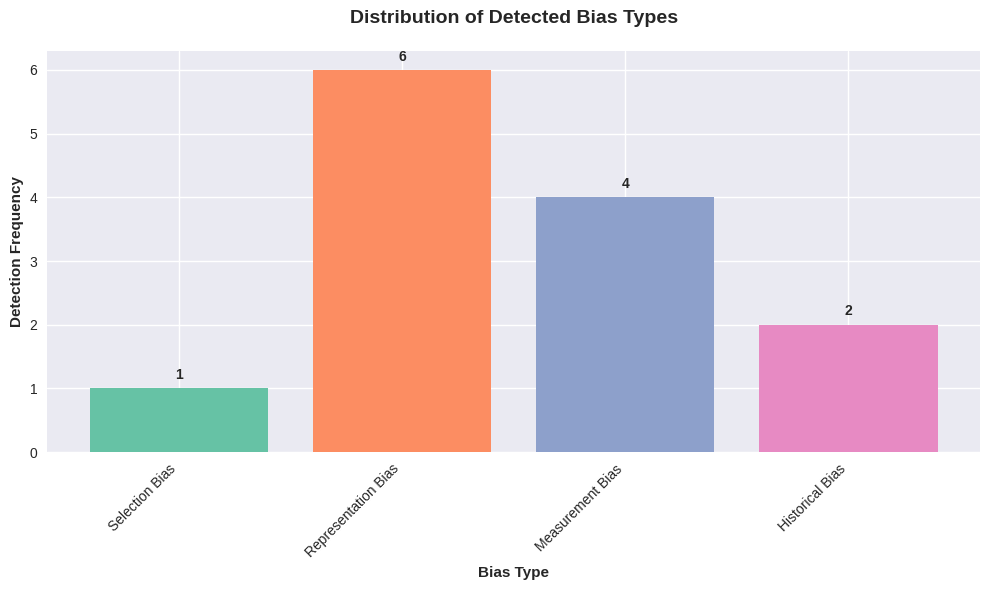

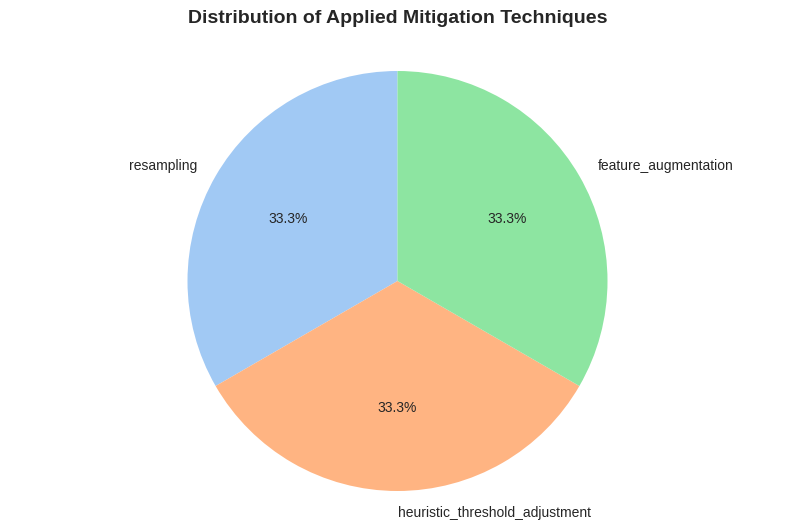

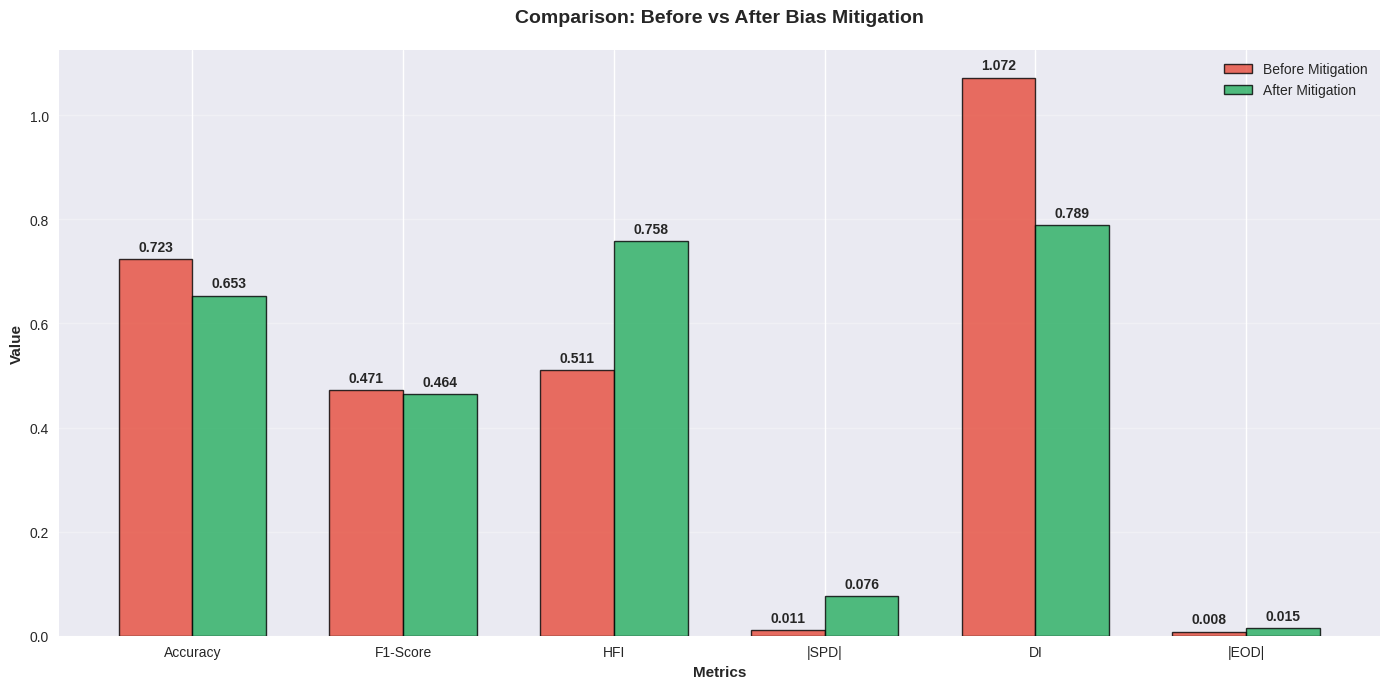

System execution completed successfully.


In [49]:
def main():
    """
    Main function that executes the complete bias detection and mitigation system.

    Coordinates the initialization, execution, and reporting of the integrated system,
    providing a single interface to execute the complete pipeline for monitoring
    and mitigating intersectional biases.
    """
    print("Starting Intersectional Bias Detection and Mitigation System...")
    print("=" * 60)

    # -------------------------------------------------------------------------
    # DATASET CONFIGURATION
    # -------------------------------------------------------------------------
    # Selection of the dataset to use for execution
    # Options: 'adult' (Adult Census) or 'german' (German Credit)
    #DATASET_TO_RUN = 'adult'

    DATASET_TO_RUN = 'german'# The test set size for german s around 300

    # -------------------------------------------------------------------------
    # SYSTEM INITIALIZATION
    # -------------------------------------------------------------------------
    # Create integrated system instance
    system = BiasMitigationSystem()

    try:
        # Configure and initialize all system components
        system.initialize_system(dataset_name=DATASET_TO_RUN)
        print(f"System initialized successfully with dataset: {DATASET_TO_RUN}")
    except ValueError as e:
        print(f"ERROR in initialization: {e}")
        return
    except Exception as e:
        print(f"Unexpected ERROR during initialization: {e}")
        return

    print("-" * 60)

    # -------------------------------------------------------------------------
    # CONTINUOUS MONITORING EXECUTION
    # -------------------------------------------------------------------------
    # Configure number of predictions to simulate production environment
    NUM_PREDICTIONS = 300
    print(f"Executing monitoring cycle with {NUM_PREDICTIONS} predictions...")

    # Execute the complete detection and mitigation pipeline
    alerts, decisions = system.run_complete_monitoring(num_predictions=NUM_PREDICTIONS)

    # -------------------------------------------------------------------------
    # FINAL REPORT GENERATION
    # -------------------------------------------------------------------------
    print("Generating final report with complete analysis...")
    system.generate_report(alerts, decisions)

    print("System execution completed successfully.")

if __name__ == "__main__":
    # Main system entry point
    main()